In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

- https://www.eurowings.com/es/informar/sobre-nosotros/tecnologia-y-flota.html
- https://www.flightaware.com/live/flight/EWG9443/history/20251121/1845Z/LEBL/EDDL
- https://www.aeropuertobarcelona-elprat.com/cast/salidas-aeropuerto-barcelona.html?t=9-12&a=2

In [2]:
df = pd.read_csv("vuelos_bcn_m1.csv")
df

,Unnamed: 0.1,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
0,0,118.0,17/11/2025 14-06-56,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189.0,Boeing 737-800,U
1,1,119.0,17/11/2025 14-06-56,Ryanair,FR846,Milan (BGY),06:10,"Retrasado, Ha salido",189.0,Boeing 737-800,S
2,2,120.0,17/11/2025 14-06-56,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156.0,Airbus A319,R
3,3,121.0,17/11/2025 14-06-56,Ryanair,FR2233,Al Aaroui (NDR),06:20,"Retrasado, Ha salido",189.0,Boeing 737-800,NaN
4,4,122.0,17/11/2025 14-06-56,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189.0,Boeing 737-800,R
...,...,...,...,...,...,...,...,...,...,...,...
1775,1775,NaN,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W44
1776,1776,NaN,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230.0,Airbus A321,W
1777,1777,NaN,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197.0,Boeing 737 MAX 8,S24
1778,1778,NaN,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230.0,Airbus A321,U31


In [3]:
df.isna().sum()[df.isna().sum() > 0] 

Unnamed: 0         1161
flight_capacity       3
Aircraft              3
Gate                 17
dtype: int64

In [4]:
df = df.drop(columns= ['Unnamed: 0', 'Unnamed: 0.1'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_scrapeo    1780 non-null   object 
 1   Name_company     1780 non-null   object 
 2   Num_flight       1780 non-null   object 
 3   Name_Destiny     1780 non-null   object 
 4   Time_flight      1780 non-null   object 
 5   flight_state     1780 non-null   object 
 6   flight_capacity  1777 non-null   float64
 7   Aircraft         1777 non-null   object 
 8   Gate             1763 non-null   object 
dtypes: float64(1), object(8)
memory usage: 125.3+ KB


In [6]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
0,17/11/2025 14-06-56,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189.0,Boeing 737-800,U
1,17/11/2025 14-06-56,Ryanair,FR846,Milan (BGY),06:10,"Retrasado, Ha salido",189.0,Boeing 737-800,S
2,17/11/2025 14-06-56,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156.0,Airbus A319,R
3,17/11/2025 14-06-56,Ryanair,FR2233,Al Aaroui (NDR),06:20,"Retrasado, Ha salido",189.0,Boeing 737-800,NaN
4,17/11/2025 14-06-56,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189.0,Boeing 737-800,R
...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W44
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230.0,Airbus A321,W
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197.0,Boeing 737 MAX 8,S24
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230.0,Airbus A321,U31


In [7]:
df[df.Gate == 'Y']

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
8,17/11/2025 14-06-56,Ryanair,FR8215,London (STN),06:45,Ha salido,197.0,Boeing 737 MAX 8,Y
43,17/11/2025 14-06-56,Ryanair,FR7808,London (LTN),10:35,Ha salido,197.0,Boeing 737 MAX 8,Y
46,17/11/2025 14-06-56,Ryanair,FR2239,Marrakech (RAK),10:45,Ha salido,189.0,Boeing 737-800,Y
52,17/11/2025 14-06-56,FLYONE Armenia,3F232,Yerevan (EVN),11:30,Ha salido,180.0,Airbus A320,Y
53,17/11/2025 14-06-56,Aer Lingus,EI563,Dublin (DUB),11:30,Ha salido,180.0,Airbus A320,Y
...,...,...,...,...,...,...,...,...,...
616,21/11/2025 14-58-40,Wizz Air Malta,W45154,Tirana (TIA),22:45,Programado,230.0,Airbus A321,Y
810,23/11/2025 15-34-22,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,Programado,180.0,Airbus A320,Y
1101,25/Nov/2025,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,"En hora, Programado",180.0,Airbus A320,Y
1696,30/Nov/2025,Bluebird Airways,BZ251,Tel Aviv (TLV),14:45,"En hora, Programado",189.0,Boeing 737-800,Y


In [8]:
df.loc[
(df['Aircraft'] == 'DBoeing 737-800'), 
'Aircraft'
] = 'Boeing 737-800'

In [9]:
df.loc[
(df['Aircraft'] == 'De Havilland Dash 8-400'), 
'Aircraft'
] = 'de Havilland Dash 8-400'

# estandarizar 

In [10]:
# AÑADIR COLUMNA DE F_TYPE
df['Aircraft'].unique()   # ESTANDARIZAR ESTO 

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', nan,
       'Airbus A330-200', 'Airbus A330-800', 'Boeing 737-700',
       'Airbus A350-900', 'BOEING 777-300ER', 'Airbus A330-900',
       'Boeing 757-200'], dtype=object)

In [11]:
# AÑADIR COLUMNA DE F_TYPE
df['Gate'].unique()   # ESTANDARIZAR ESTO 

array(['U', 'S', 'R', nan, 'Y', 'W', 'M', 'S21', 'R9', 'S22', 'U31',
       'S24', 'S23', 'R10', 'S20', 'U32', 'W45', 'R12', 'U35', 'S25',
       'Y57', 'U36', 'W44', 'U38', 'U34', 'U33', 'Y58', 'R14', 'R11',
       'M6', 'W42', 'Y55', 'R13', 'M8', 'W46', 'M3', 'W49', 'Y54', 'U37',
       'U41', 'R15', 'R19', 'S26', 'Y59', 'Y63', 'U39', 'Y56', 'M1'],
      dtype=object)

In [12]:
df[(df.Name_Destiny == 'Valletta (MLA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
164,17/11/2025 14-06-56,Ryanair,FR1527,Valletta (MLA),21:50,"Retrasado, Ha salido",197.0,Boeing 737 MAX 8,S
443,20/11/2025 14-38-34,Ryanair,FR1527,Valletta (MLA),21:20,Programado,189.0,Boeing 737-800,U
466,21/11/2025 14-58-40,Ryanair,FR5752,Valletta (MLA),08:40,Ha salido,197.0,Boeing 737 MAX 8,U
580,21/11/2025 14-58-40,Ryanair,FR1527,Valletta (MLA),20:05,Ha salido,189.0,Boeing 737-800,U
695,22/Nov/2025,Ryanair,FR5752,Valletta (MLA),17:10,"En hora, Ha salido",197.0,Boeing 737 MAX 8,U34
787,23/11/2025 15-34-22,Ryanair,FR1527,Valletta (MLA),12:30,Ha salido,189.0,Boeing 737-800,U34
887,23/11/2025 15-34-22,Ryanair,FR5752,Valletta (MLA),21:45,"Retrasado, Ha salido 22:20",197.0,Boeing 737 MAX 8,S20
1055,24/Nov/2025,Ryanair,FR1527,Valletta (MLA),21:50,"Retrasado, Ha salido 22:07",197.0,Boeing 737 MAX 8,S21
1327,27/Nov/2025,Ryanair,FR1527,Valletta (MLA),21:20,"Retrasado, Ha salido 21:45",189.0,Boeing 737-800,U37
1350,28/Nov/2025,Ryanair,FR5752,Valletta (MLA),08:40,"Retrasado, Ha salido 08:51",197.0,Boeing 737 MAX 8,U31


In [13]:
df[(df.Gate == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate
42,17/11/2025 14-06-56,Easyjet,U22324,London (LTN),10:25,"Retrasado, Ha salido",186.0,Airbus A320neo,M
45,17/11/2025 14-06-56,Easyjet,U28056,London (LGW),10:40,"Retrasado, Ha salido",180.0,Airbus A320,M
51,17/11/2025 14-06-56,Easyjet,U22002,Manchester (MAN),11:20,"Retrasado, Ha salido",180.0,Airbus A320,M
104,17/11/2025 14-06-56,Easyjet,U23372,Liverpool (LPL),17:00,Ha salido,156.0,Airbus A319,M
131,17/11/2025 14-06-56,Easyjet,U28058,London (LGW),19:45,Ha salido,156.0,Airbus A319,M
166,17/11/2025 14-06-56,Easyjet,U22706,Bristol (BRS),21:55,Ha salido,180.0,Airbus A320,M
228,18/11/2025 14-12-47,Easyjet,U28058,London (LGW),19:45,Ha salido,156.0,Airbus A319,M
266,19/11/2025 14-33-06,Easyjet,U22704,Bristol (BRS),10:55,Ha salido,186.0,Airbus A320neo,M
305,19/11/2025 14-33-06,Easyjet,U28058,London (LGW),19:45,Ha salido,180.0,Airbus A320,M
316,19/11/2025 14-33-06,Easyjet,U22326,London (LTN),20:55,Ha salido,156.0,Airbus A319,M


In [14]:
# AÑADIR COLUMNA DE F_TYPE
df['Name_Destiny'].unique()

array(['Rome (FCO)', 'Milan (BGY)', 'Geneva (GVA)', 'Al Aaroui (NDR)',
       'Budapest (BUD)', 'Lisbon (LIS)', 'London (LGW)', 'Krakow (KRK)',
       'London (STN)', 'Strasbourg (SXB)', 'Milan (MXP)', 'Ibiza (IBZ)',
       'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 'Copenhagen (CPH)',
       'Napoli (NAP)', 'Bologna (BLQ)', 'Vienna (VIE)',
       'Ouarzazate (OZZ)', 'Rabat (RBA)', 'Stuttgart (STR)',
       'Bucharest (OTP)', 'Tirana (TIA)', 'Asturias (OVD)',
       'Basel, Switzerland/Mulhouse (BSL)', 'Charleroi (CRL)',
       'Rotterdam (RTM)', 'Dusseldorf (DUS)', 'Porto (OPO)',
       'Belgrade (BEG)', 'Amsterdam (AMS)', 'Paris (ORY)',
       'Liverpool (LPL)', 'Warsaw (WAW)', 'London (LTN)',
       "Nice/Cote D'Azur (NCE)", 'Marrakech (RAK)', 'Beauvais (BVA)',
       'Dublin (DUB)', 'Prague (PRG)', 'Manchester (MAN)',
       'Yerevan (EVN)', 'Birmingham (BHX)', 'Venice (VCE)',
       'Leeds Bradford (LBA)', 'Torino (TRN)', 'Istanbul (SAW)',
       'Lyon (LYS)', 'Bratislava (BTS)',

In [15]:
df["Gate"] = df["Gate"].str.extract(r'([A-Za-z]+)') # dejar solo letra

In [16]:
# LISTA DE AEROPUERTOS NACIONALES
vue_nac = ['Ibiza (IBZ)', 'Palma de Mallorca (PMI)', 'Sevilla (SVQ)', 
           'Malaga (AGP)', 'Asturias (OVD)', 'Murcia (RMU)', 'Vitoria (VIT)', 
           'Palmerola (XPL)'] 
puertas = ['Y', 'W', 'M']  # PUERTAS DE VUELOS QUE TIENES QUE PASAR CONTROL DE PASAPORTES 
fin = []
for gate, name in zip(df['Gate'], df['Name_Destiny']):
    if pd.isnull(gate):
        fin.append(np.nan)
    elif gate in puertas:
        fin.append("INT")
    elif name in vue_nac:
        fin.append("NAC")
    else:
        fin.append("EU")
print(fin)

['EU', 'EU', 'EU', nan, 'EU', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'NAC', 'NAC', 'NAC', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', nan, 'EU', 'EU', 'INT', 'EU', 'NAC', 'EU', 'EU', 'EU', 'EU', 'NAC', 'EU', 'INT', 'EU', 'EU', nan, 'EU', 'INT', 'EU', 'EU', 'INT', 'INT', 'EU', 'INT', 'INT', 'EU', 'INT', 'EU', 'INT', 'INT', 'INT', 'INT', 'EU', nan, 'EU', 'EU', 'EU', 'INT', 'INT', 'NAC', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'INT', 'EU', 'NAC', 'EU', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', nan, 'INT', nan, 'EU', 'INT', 'EU', 'INT', 'EU', 'NAC', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', 'EU', 'NAC', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'NAC', 'EU', 'INT', 'INT', 'INT', nan, 'EU', 'NAC', 'EU', 'EU', 'EU', 'INT', 'EU', 'INT', 'NAC', 'INT', 'EU', 'EU', 'INT', 'EU', 'EU', 'EU', 'INT', 'EU', 'INT', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'EU', 'INT', 'INT', 'INT', 'EU', nan, 'EU'

In [17]:
df['Type_f'] = fin # guardo la variable en la columna nueva

In [18]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,17/11/2025 14-06-56,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189.0,Boeing 737-800,U,EU
1,17/11/2025 14-06-56,Ryanair,FR846,Milan (BGY),06:10,"Retrasado, Ha salido",189.0,Boeing 737-800,S,EU
2,17/11/2025 14-06-56,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156.0,Airbus A319,R,EU
3,17/11/2025 14-06-56,Ryanair,FR2233,Al Aaroui (NDR),06:20,"Retrasado, Ha salido",189.0,Boeing 737-800,NaN,NaN
4,17/11/2025 14-06-56,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189.0,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230.0,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197.0,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230.0,Airbus A321,U,EU


In [19]:
# convertir en string ya que habia mezcla
df["fecha_scrapeo"] = df["fecha_scrapeo"].astype(str)

In [20]:
s = '16/11/2025 23-03-05'
s.split(" ")[0]

'16/11/2025'

In [21]:
s = '16/11/2025'
s.split(" ")[0]

'16/11/2025'

In [22]:
# QUITAR LA HORA 
f = lambda x: x.split(" ")[0]
df["fecha_scrapeo"] = df["fecha_scrapeo"].apply(f)

#df["fecha_scrapeo"] = df["fecha_scrapeo"].str.strip(" ")[0]

In [23]:
df.tail()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230.0,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197.0,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230.0,Airbus A321,U,EU
1779,30/Nov/2025,Ryanair,FR9406,Fes (FEZ),23:15,"En hora, Programado",189.0,Boeing 737-800,Y,INT


In [24]:
# Convertir a datetime con el dia como primero 
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"],
                                     format="mixed" # especificar formato %d/%m/%Y
                                     #errors="coerce"
                                    )
# Estandarizar al formato deseado: 16/Nov/2025
df["fecha_scrapeo"] = df["fecha_scrapeo"].dt.strftime("%d/%b/%Y")

In [25]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,17/Nov/2025,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189.0,Boeing 737-800,U,EU
1,17/Nov/2025,Ryanair,FR846,Milan (BGY),06:10,"Retrasado, Ha salido",189.0,Boeing 737-800,S,EU
2,17/Nov/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156.0,Airbus A319,R,EU
3,17/Nov/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"Retrasado, Ha salido",189.0,Boeing 737-800,NaN,NaN
4,17/Nov/2025,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189.0,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239.0,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230.0,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197.0,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230.0,Airbus A321,U,EU


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_scrapeo    1780 non-null   object 
 1   Name_company     1780 non-null   object 
 2   Num_flight       1780 non-null   object 
 3   Name_Destiny     1780 non-null   object 
 4   Time_flight      1780 non-null   object 
 5   flight_state     1780 non-null   object 
 6   flight_capacity  1777 non-null   float64
 7   Aircraft         1777 non-null   object 
 8   Gate             1763 non-null   object 
 9   Type_f           1763 non-null   object 
dtypes: float64(1), object(9)
memory usage: 139.2+ KB


In [27]:
df["flight_capacity"] = df["flight_capacity"].astype('Int64')

In [28]:
df['flight_capacity'].tail(40)

1740    180
1741    189
1742    189
1743    180
1744    230
1745    189
1746    239
1747    180
1748    189
1749    239
1750    197
1751    180
1752    144
1753    189
1754    180
1755    189
1756    142
1757    189
1758    239
1759    197
1760    189
1761    186
1762    239
1763    189
1764    174
1765    189
1766    189
1767    189
1768    230
1769    180
1770    156
1771    239
1772    197
1773    186
1774    180
1775    239
1776    230
1777    197
1778    230
1779    189
Name: flight_capacity, dtype: Int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    1780 non-null   object
 1   Name_company     1780 non-null   object
 2   Num_flight       1780 non-null   object
 3   Name_Destiny     1780 non-null   object
 4   Time_flight      1780 non-null   object
 5   flight_state     1780 non-null   object
 6   flight_capacity  1777 non-null   Int64 
 7   Aircraft         1777 non-null   object
 8   Gate             1763 non-null   object
 9   Type_f           1763 non-null   object
dtypes: Int64(1), object(9)
memory usage: 140.9+ KB


In [30]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,17/Nov/2025,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189,Boeing 737-800,U,EU
1,17/Nov/2025,Ryanair,FR846,Milan (BGY),06:10,"Retrasado, Ha salido",189,Boeing 737-800,S,EU
2,17/Nov/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156,Airbus A319,R,EU
3,17/Nov/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,"Retrasado, Ha salido",189,Boeing 737-800,NaN,NaN
4,17/Nov/2025,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,"En hora, Ha salido",239,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,"Retrasado, Programado 23:18",230,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,"En hora, Programado",197,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,"En hora, Programado",230,Airbus A321,U,EU


In [31]:
f = lambda x: x.split(", ")[0]
df["flight_state"] = df["flight_state"].apply(f)
# quedarme con lo primero de esa columna

In [32]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,17/Nov/2025,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189,Boeing 737-800,U,EU
1,17/Nov/2025,Ryanair,FR846,Milan (BGY),06:10,Retrasado,189,Boeing 737-800,S,EU
2,17/Nov/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156,Airbus A319,R,EU
3,17/Nov/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,Retrasado,189,Boeing 737-800,NaN,NaN
4,17/Nov/2025,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,Retrasado,230,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,197,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,230,Airbus A321,U,EU


In [33]:
df['flight_state'].value_counts()

flight_state
En hora       800
Retrasado     477
Ha salido     427
Programado     76
Name: count, dtype: int64

In [34]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,17/Nov/2025,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189,Boeing 737-800,U,EU
1,17/Nov/2025,Ryanair,FR846,Milan (BGY),06:10,Retrasado,189,Boeing 737-800,S,EU
2,17/Nov/2025,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156,Airbus A319,R,EU
3,17/Nov/2025,Ryanair,FR2233,Al Aaroui (NDR),06:20,Retrasado,189,Boeing 737-800,NaN,NaN
4,17/Nov/2025,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,30/Nov/2025,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
1776,30/Nov/2025,Wizz Air Malta,W45154,Tirana (TIA),22:45,Retrasado,230,Airbus A321,W,INT
1777,30/Nov/2025,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,197,Boeing 737 MAX 8,S,EU
1778,30/Nov/2025,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,230,Airbus A321,U,EU


In [35]:
df["fecha_scrapeo"] = pd.to_datetime(df["fecha_scrapeo"])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_scrapeo    1780 non-null   datetime64[ns]
 1   Name_company     1780 non-null   object        
 2   Num_flight       1780 non-null   object        
 3   Name_Destiny     1780 non-null   object        
 4   Time_flight      1780 non-null   object        
 5   flight_state     1780 non-null   object        
 6   flight_capacity  1777 non-null   Int64         
 7   Aircraft         1777 non-null   object        
 8   Gate             1763 non-null   object        
 9   Type_f           1763 non-null   object        
dtypes: Int64(1), datetime64[ns](1), object(8)
memory usage: 140.9+ KB


In [37]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-11-17,Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189,Boeing 737-800,U,EU
1,2025-11-17,Ryanair,FR846,Milan (BGY),06:10,Retrasado,189,Boeing 737-800,S,EU
2,2025-11-17,easyJet Europe,EC7105,Geneva (GVA),06:15,Ha salido,156,Airbus A319,R,EU
3,2025-11-17,Ryanair,FR2233,Al Aaroui (NDR),06:20,Retrasado,189,Boeing 737-800,NaN,NaN
4,2025-11-17,Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Wizz Air,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
1776,2025-11-30,Wizz Air Malta,W45154,Tirana (TIA),22:45,Retrasado,230,Airbus A321,W,INT
1777,2025-11-30,Ryanair,FR5220,Bologna (BLQ),22:50,En hora,197,Boeing 737 MAX 8,S,EU
1778,2025-11-30,Wizz Air,W61706,Gdansk (GDN),22:50,En hora,230,Airbus A321,U,EU


In [38]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f


In [39]:
# LISTA DE 
compi = ["Ryanair", "BUZZ", "Lauda Europe", "Ryanair UK"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]
#norw = ["Norwegian Air Shuttle", "Norwegian Air Sweden AOC"]
grupo = []
for x in df['Name_company']:
    if x in compi:
        grupo.append("Grupo Ryanair")
    elif x in easy:
        grupo.append("Grupo easy")
    elif x in wizz:
        grupo.append("Grupo wizz")
    #elif x in norw:
        #grupo.append("Grupo Norwegian")
    else:
        grupo.append(x)
print(grupo)

['Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Norwegian Air Sweden AOC', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo wizz', 'Volotea', 'Air Arabia Maroc', 'Eurowings', 'Grupo wizz', 'Grupo wizz', 'Grupo wizz', 'Volotea', 'Grupo easy', 'Grupo Ryanair', 'Transavia', 'Eurowings', 'Grupo Ryanair', 'Grupo Ryanair', 'Air Serbia', 'Grupo easy', 'Transavia', 'Transavia', 'Grupo wizz', 'Grupo Ryanair', 'Grupo wizz', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo easy', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo easy', 'FLYONE Armenia', 'Aer Lingus', 'Grupo Ryanair', 'Transavia', 'Grupo Ryanair', 'Grupo easy', 'Grupo Ryanair', 'Grupo Ryanair', 'Jet2', 'Grupo Ryanair', 'Grupo Ryanair', 'Grupo Ryanair', '

In [40]:
df['Name_company'] = grupo

In [41]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00,Ha salido,189,Boeing 737-800,U,EU
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10,Retrasado,189,Boeing 737-800,S,EU
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15,Ha salido,156,Airbus A319,R,EU
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20,Retrasado,189,Boeing 737-800,NaN,NaN
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25,Ha salido,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
1776,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45,Retrasado,230,Airbus A321,W,INT
1777,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50,En hora,197,Boeing 737 MAX 8,S,EU
1778,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50,En hora,230,Airbus A321,U,EU


In [42]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f


In [43]:
#df.groupby(['fecha_scrapeo', 'Name_company', ''])

In [44]:
dest_counts = df["Aircraft"].value_counts()
top40 = dest_counts.head(30)
top40_sorted = top40.sort_values(ascending=True)

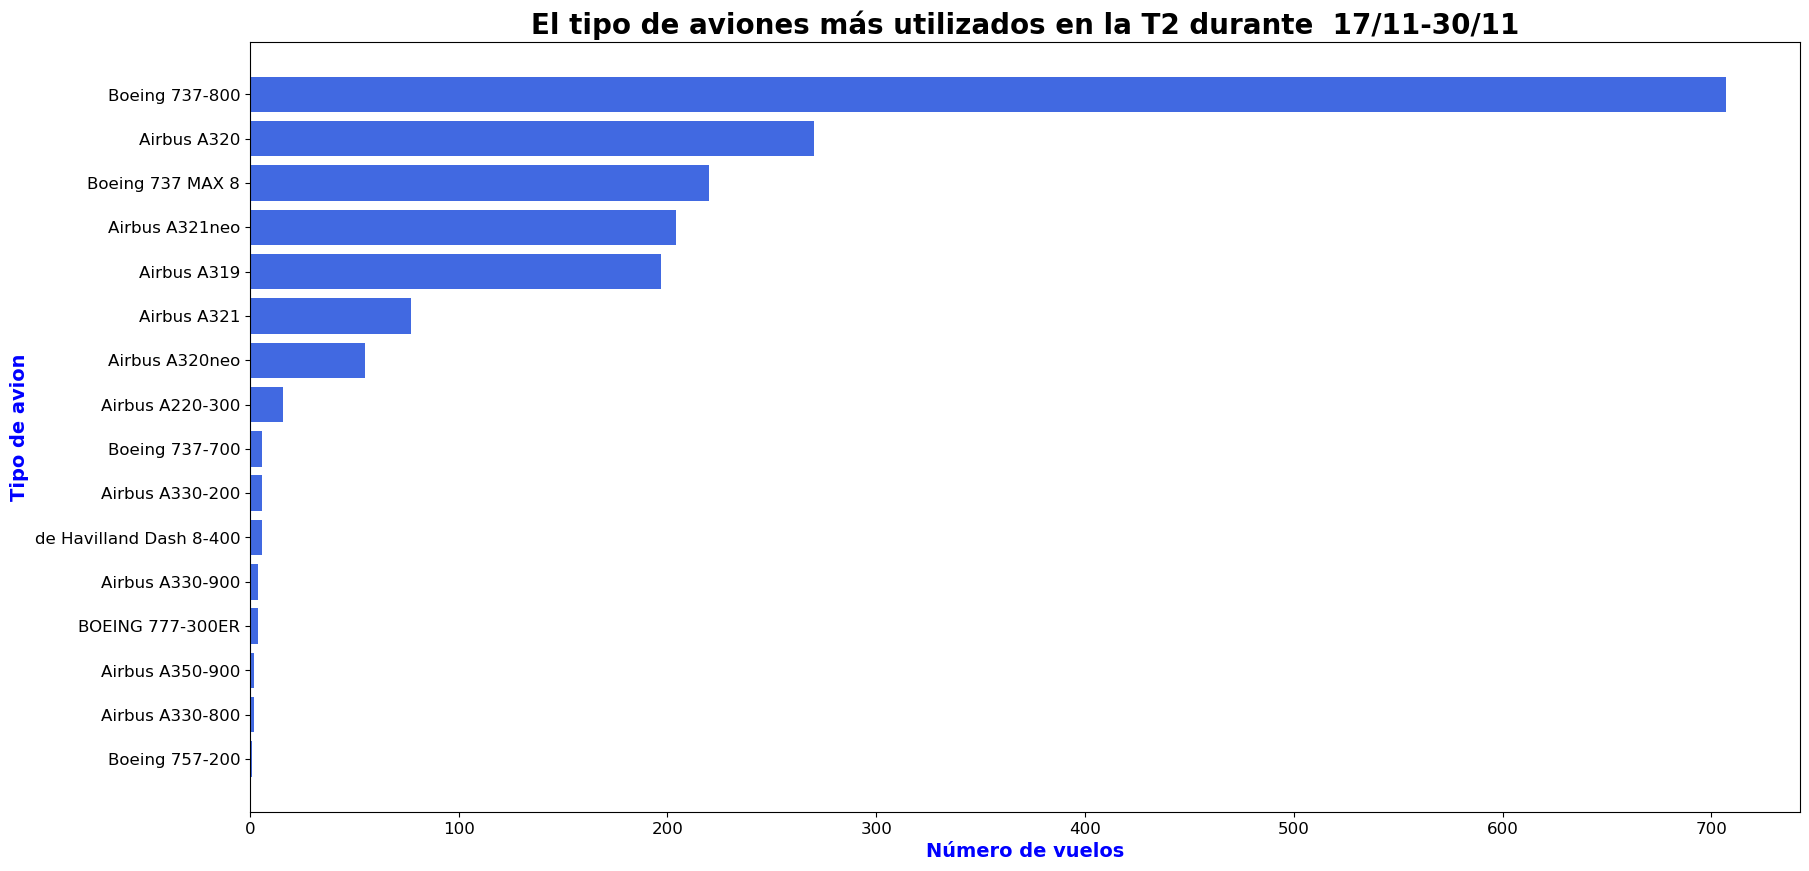

In [45]:
plt.figure(figsize=(20,10))
plt.barh(top40_sorted.index, top40_sorted.values, color="royalblue")

plt.title("El tipo de aviones más utilizados en la T2 durante  17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [46]:
dest_counts = df["Type_f"].value_counts()
top41 = dest_counts.head(30)
top41_sorted = top41.sort_values(ascending=True)

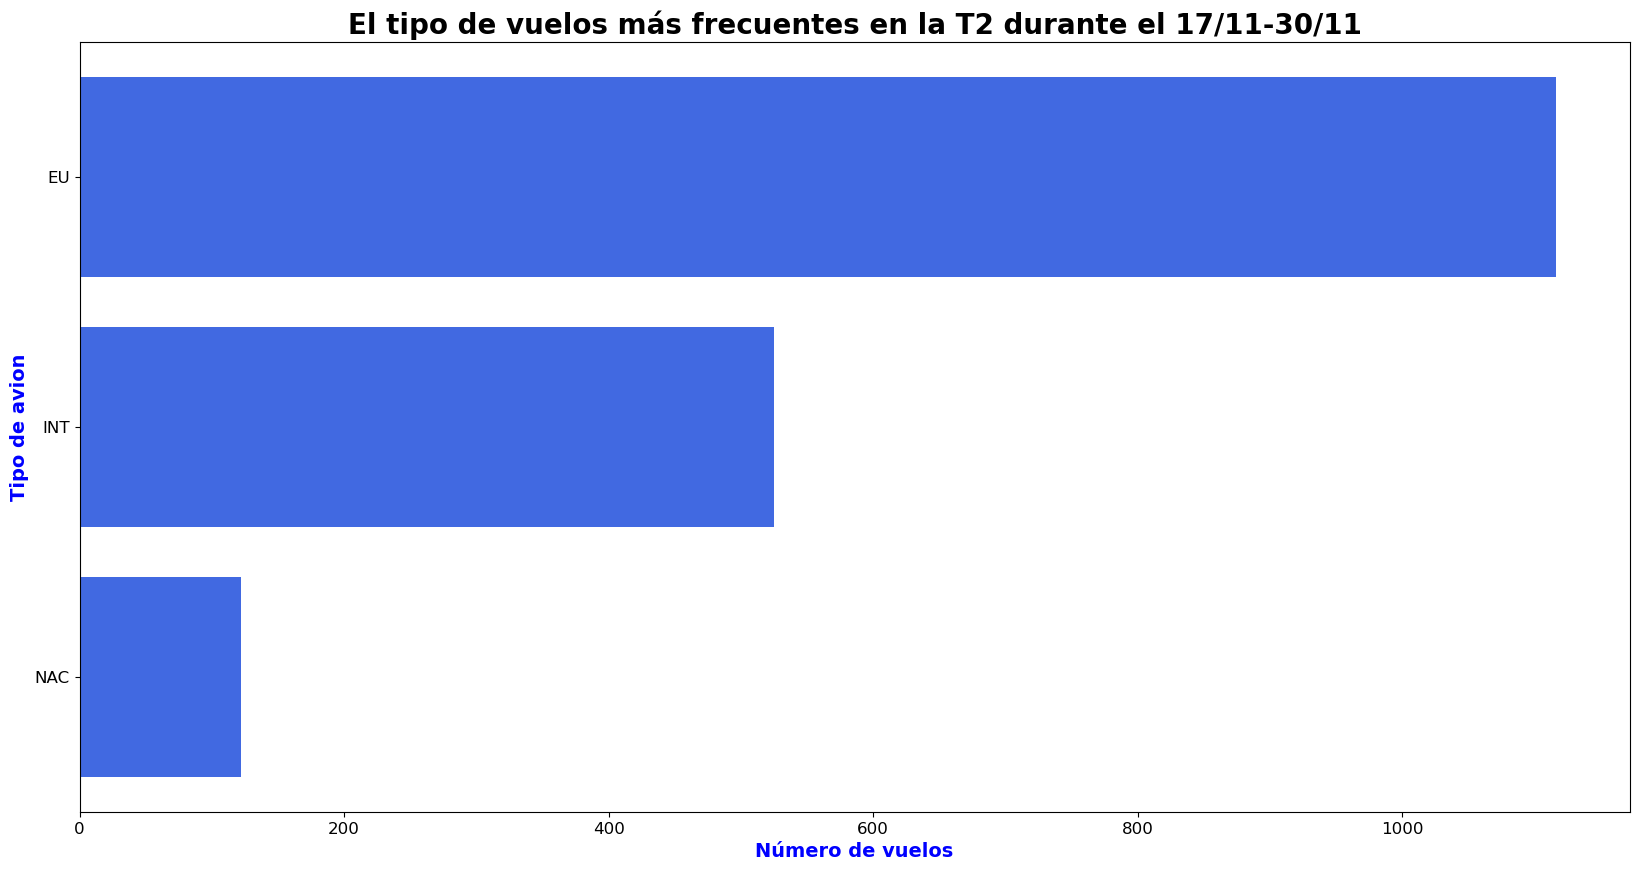

In [47]:
plt.figure(figsize=(20,10))
plt.barh(top41_sorted.index, top41_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante el 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [48]:
df["Type_f"].unique()

array(['EU', nan, 'INT', 'NAC'], dtype=object)

In [49]:
compi = ["Programado", "En hora", "Ha salido"]
easy = ["Retrasado"]

est = []
for x in df['flight_state']:
    if x in compi: 
        est.append("En hora")
    elif x in easy:
        est.append("Retrasado")
print(est)
# objetivo de unificar y estandarizar 

['En hora', 'Retrasado', 'En hora', 'Retrasado', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'Retrasado', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'Retrasado', 'En hora', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'En hora', 'Retrasado', 'Retrasado', 'Retrasado', 'Retrasado', 'Retrasado', 'En hora', 'En hora', 'Retrasado', 'Retrasado', 'En hora', 'En hora', '

In [50]:
df['flight_state'] = est

In [51]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00,En hora,189,Boeing 737-800,U,EU
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10,Retrasado,189,Boeing 737-800,S,EU
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15,En hora,156,Airbus A319,R,EU
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20,Retrasado,189,Boeing 737-800,NaN,NaN
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25,En hora,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55,En hora,239,Airbus A321neo,W,INT
1776,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45,Retrasado,230,Airbus A321,W,INT
1777,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50,En hora,197,Boeing 737 MAX 8,S,EU
1778,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50,En hora,230,Airbus A321,U,EU


In [52]:
dest_counts = df["flight_state"].value_counts()
top42 = dest_counts.head(30)
top42_sorted = top42.sort_values(ascending=True)

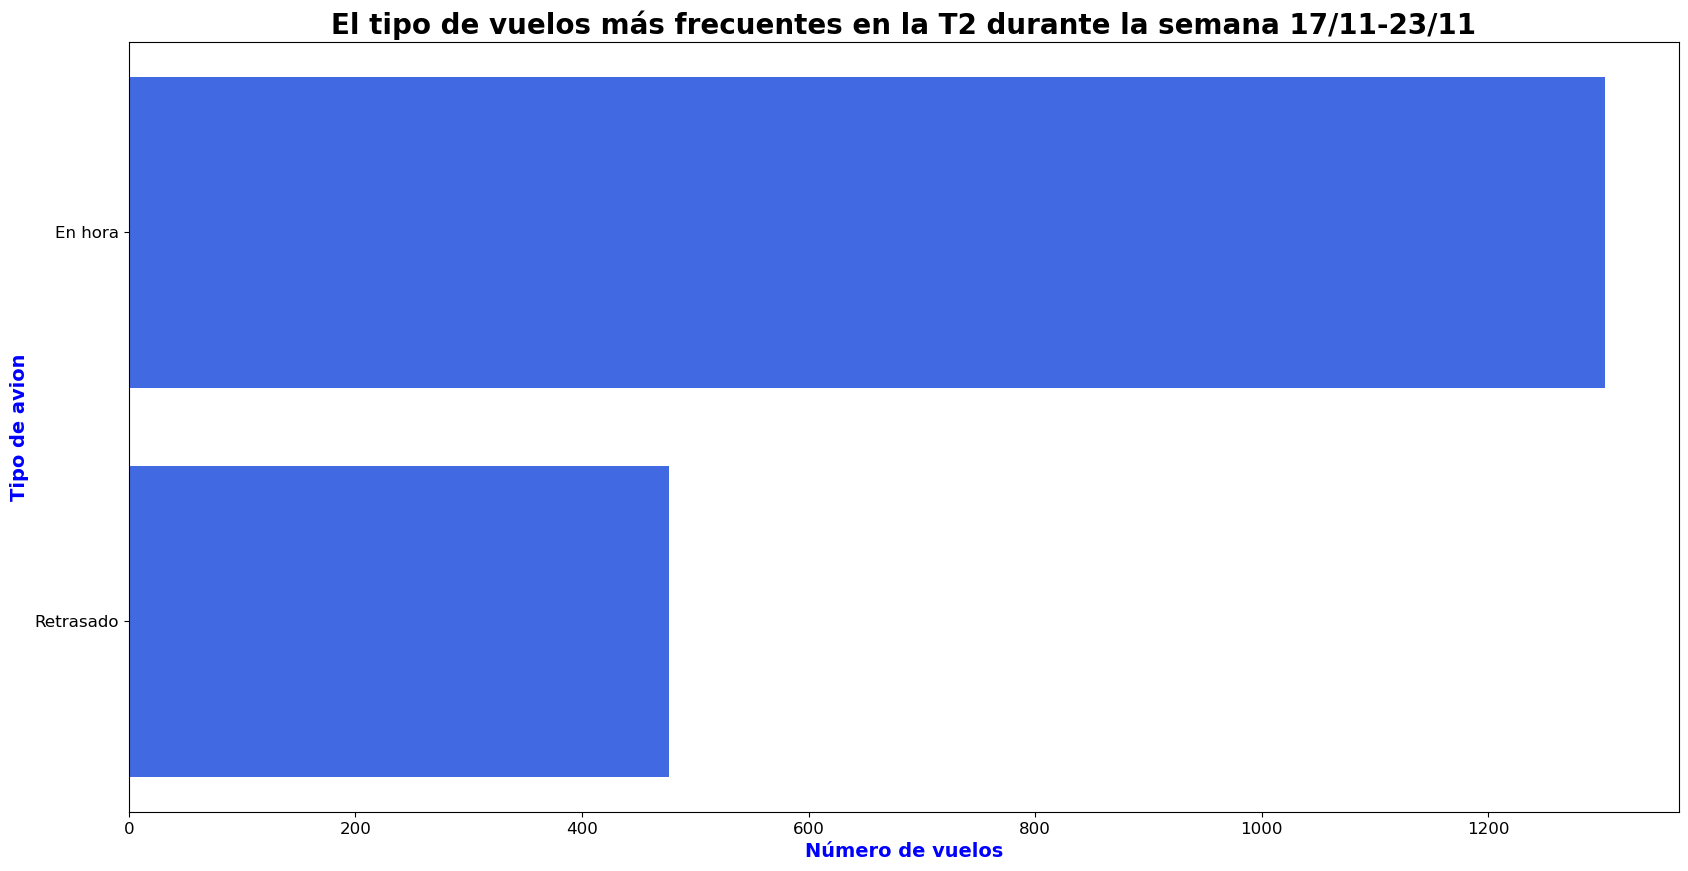

In [53]:
plt.figure(figsize=(20,10))
plt.barh(top42_sorted.index, top42_sorted.values, color="royalblue")

plt.title("El tipo de vuelos más frecuentes en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

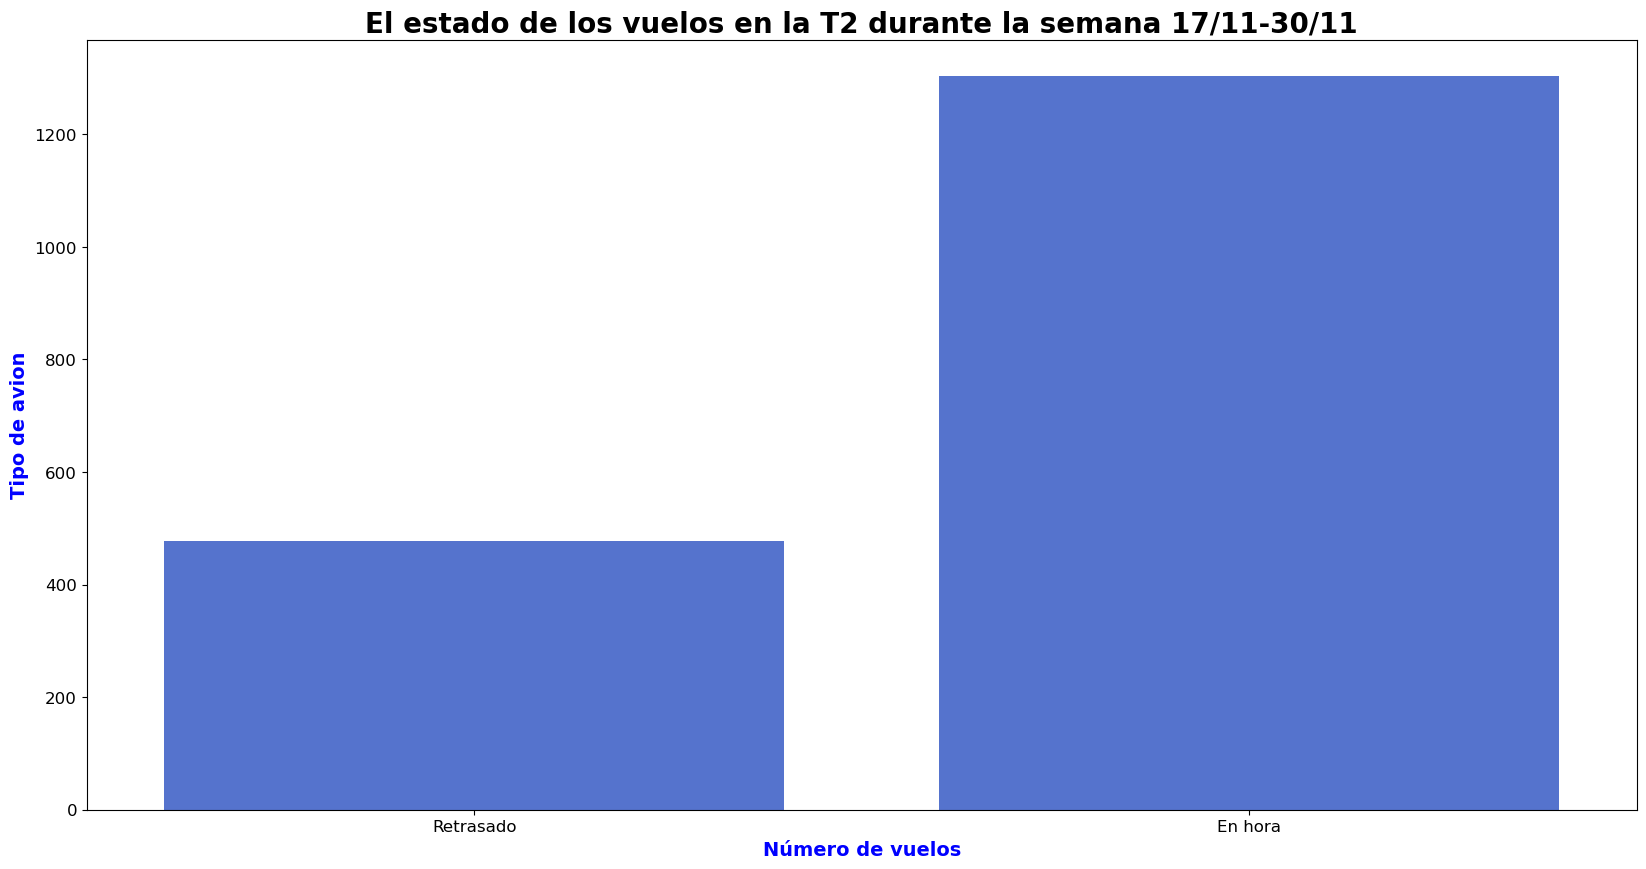

In [54]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("El estado de los vuelos en la T2 durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [55]:
dest_counts = df["Gate"].value_counts()
top43 = dest_counts.head(30)
top43_sorted = top43.sort_values(ascending=True)

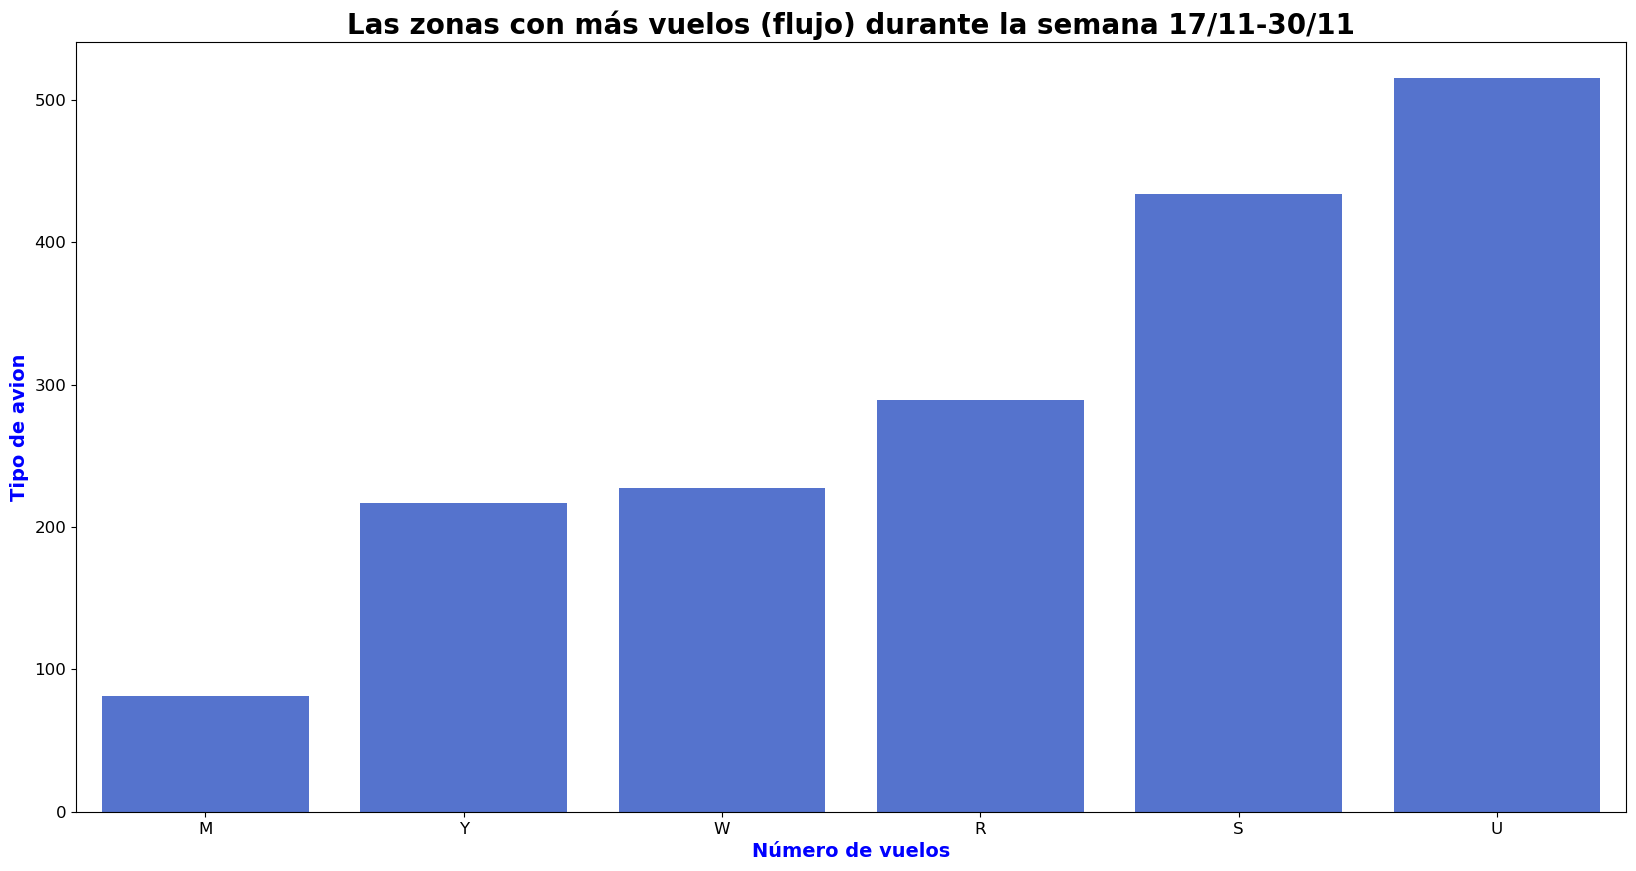

In [56]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top43_sorted.index, y=top43_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las zonas con más vuelos (flujo) durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [57]:
dest_counts = df["Name_company"].value_counts()
top44 = dest_counts.head(30)
top44_sorted = top44.sort_values(ascending=True)

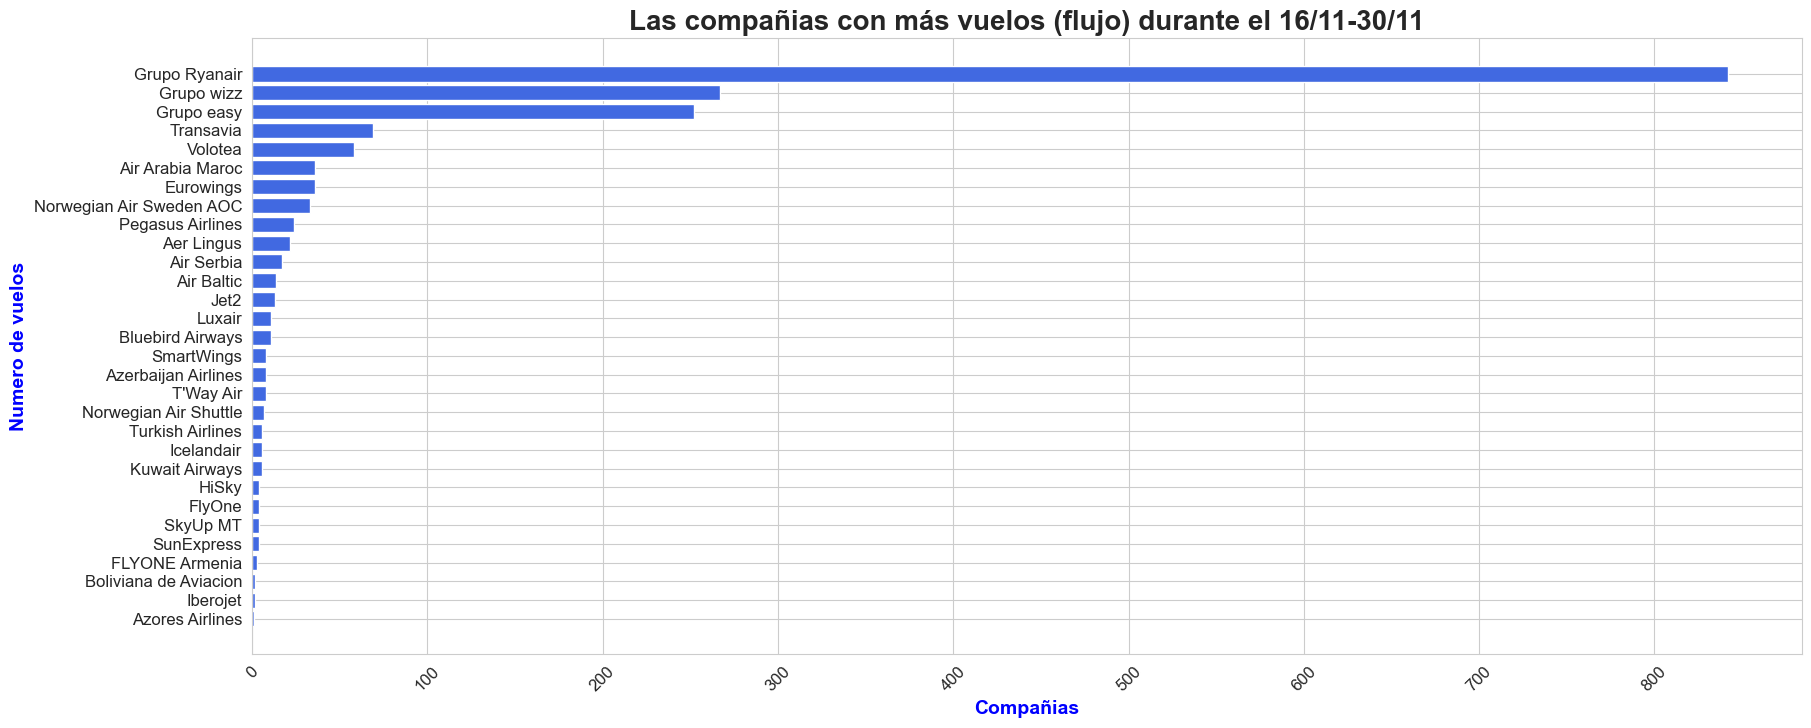

In [58]:
sns.set_style("whitegrid")  # Estilo de fondo
sns.set_palette("tab10") 

plt.figure(figsize=(20,8))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
plt.barh(top44_sorted.index, top44_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las compañias con más vuelos (flujo) durante el 16/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Compañias", fontsize=14, weight='bold', color='blue')
plt.ylabel("Numero de vuelos", fontsize=14, weight='bold', color='blue')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [59]:
df['Time_flight'] = pd.to_datetime(df['Time_flight'].astype(str), format="%H:%M").dt.time
#df['hora'] = pd.to_datetime(df['hora'].astype(str), format='%H:%M:%S').dt.time

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_scrapeo    1780 non-null   datetime64[ns]
 1   Name_company     1780 non-null   object        
 2   Num_flight       1780 non-null   object        
 3   Name_Destiny     1780 non-null   object        
 4   Time_flight      1780 non-null   object        
 5   flight_state     1780 non-null   object        
 6   flight_capacity  1777 non-null   Int64         
 7   Aircraft         1777 non-null   object        
 8   Gate             1763 non-null   object        
 9   Type_f           1763 non-null   object        
dtypes: Int64(1), datetime64[ns](1), object(8)
memory usage: 140.9+ KB


In [61]:
# Time_flight      851 non-null    object   convertir en datetime
# añadir columna weed_day

In [62]:
df.head()

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,NaN
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU


In [63]:
# DEJA EL RESTO DE FILAS EXCESPTO LAS QUE TENGAN ESA FECHA 
df = df[df['fecha_scrapeo'] != '2025-11-16']

In [64]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,NaN
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU
...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT
1776,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT
1777,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU
1778,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU


In [65]:
type(df['Time_flight'].iloc[0])

datetime.time

In [66]:
df['week_day'] = df['fecha_scrapeo'].dt.day_name(locale='es_ES')

In [67]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,NaN,Lunes
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
1776,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo
1777,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo
1778,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo


In [68]:
dest_counts = df["week_day"].value_counts()

orden_semana = [
    'Lunes', 'Martes', 'Miércoles', 'Jueves',
    'Viernes', 'Sábado', 'Domingo'
]

# Convertimos el índice a categoría ordenada
dest_counts.index = pd.Categorical(dest_counts.index, categories=orden_semana, ordered=True)

# ordenar
top4_sorted = dest_counts.sort_index()


In [69]:
df_counts = df.groupby(["fecha_scrapeo", "week_day"]).size().reset_index(name="n_vuelos")


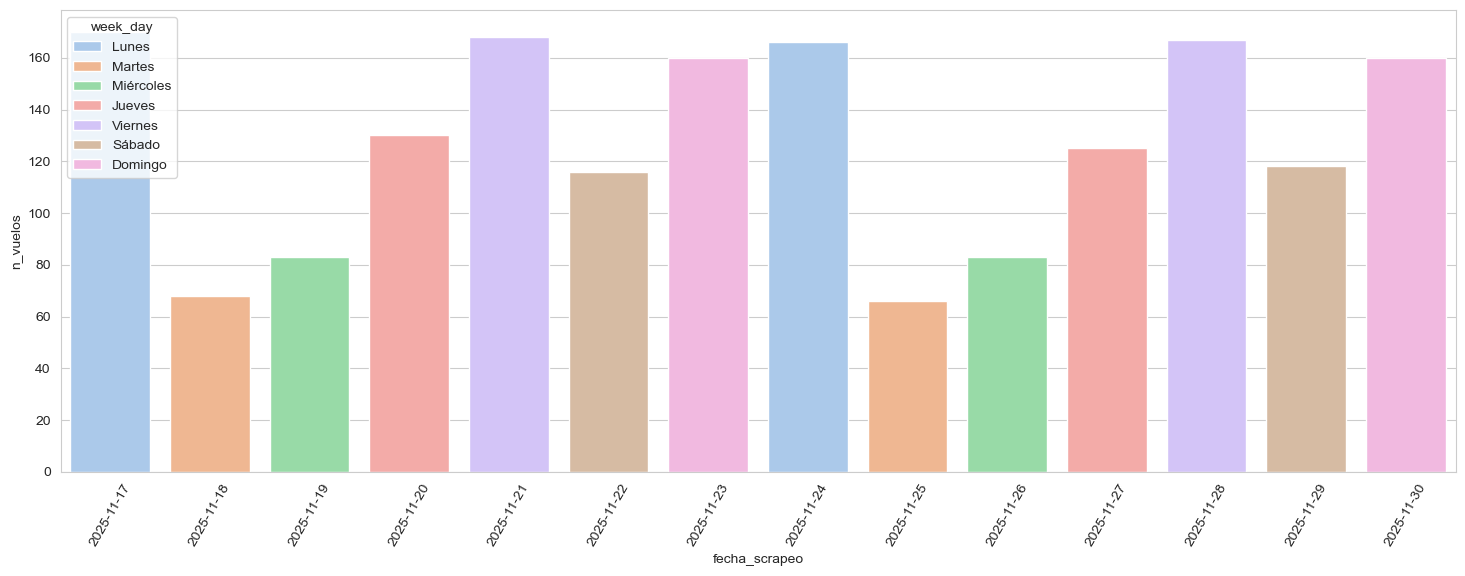

In [70]:
plt.figure(figsize=(18,6))
sns.barplot(
    data=df_counts,
    x="fecha_scrapeo",
    y="n_vuelos",
    hue="week_day",
    palette="pastel"
)
plt.xticks(rotation=60)
plt.show()


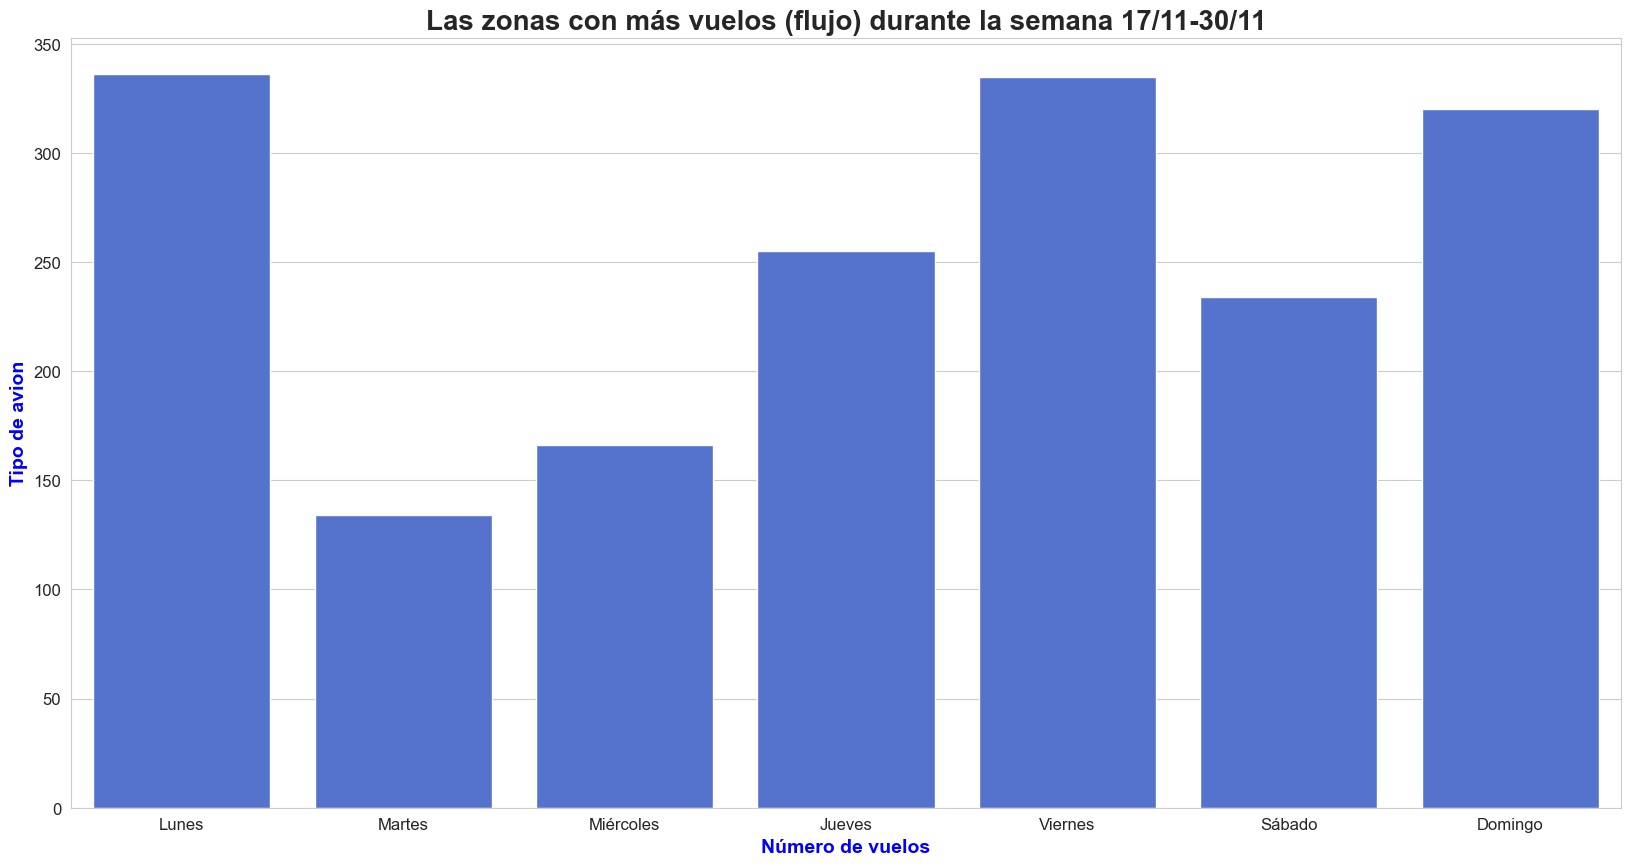

In [71]:
plt.figure(figsize=(20,10))

#sns.barplot(x=df['fecha_scrapeo'], y=top42_sorted, color="royalblue")
sns.barplot(x=top4_sorted.index, y=top4_sorted.values, color="royalblue")
#sns.barplot(x=top42_sorted.index, y=top42_sorted.values, color="red")

plt.title("Las zonas con más vuelos (flujo) durante la semana 17/11-30/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [72]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
190,2025-11-18,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,156,Airbus A319,S,EU,Martes
254,2025-11-19,Eurowings,EW9441,Dusseldorf (DUS),09:45:00,En hora,156,Airbus A319,S,EU,Miércoles
281,2025-11-19,Eurowings,EW2521,Stuttgart (STR),15:10:00,Retrasado,156,Airbus A319,S,EU,Miércoles
375,2025-11-20,Eurowings,EW521,Cologne-Bonn (CGN),13:25:00,Retrasado,156,Airbus A319,S,EU,Jueves
756,2025-11-23,Eurowings,EW7521,Hamburg (HAM),09:25:00,En hora,150,Airbus A319,S,EU,Domingo
852,2025-11-23,Eurowings,EW9443,Dusseldorf (DUS),19:35:00,En hora,150,Airbus A319,U,EU,Domingo
918,2025-11-24,Eurowings,EW2521,Stuttgart (STR),09:20:00,Retrasado,156,Airbus A319,S,EU,Lunes
1169,2025-11-26,Eurowings,EW2521,Stuttgart (STR),15:10:00,En hora,156,Airbus A319,S,EU,Miércoles
1641,2025-11-30,Eurowings,EW7521,Hamburg (HAM),09:25:00,Retrasado,150,Airbus A319,U,EU,Domingo


In [73]:
# CAMBIAR CAPACIDAD A 150 

In [74]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 150  

In [75]:
df.loc[
(df['Aircraft'] == 'Airbus A320neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [76]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 180 

In [77]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 226

In [78]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Eurowings'),
'flight_capacity'
] = 232

In [79]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Transavia'),
'flight_capacity'
] = 232

In [80]:
df.loc[
(df['Aircraft'] == 'Airbus A319') & 
(df['Name_company'] == 'Air Serbia'),
'flight_capacity'
] = 144 

In [81]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Air Arabia Maroc'),
'flight_capacity'
] = 174   # si es eurowings y tiene ese tipo de avion ponerle estas capacidades 

In [82]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'Pegasus Airlines'),
'flight_capacity'
] = 220   

In [83]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 189

In [84]:
df.loc[
(df['Aircraft'] == 'Airbus A321neo') & 
(df['Name_company'] == 'Jet2'),
'flight_capacity'
] = 232 

In [85]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Norwegian Air Sweden AOC'),
'flight_capacity'
] = 189

In [86]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'Aer Lingus'),
'flight_capacity'
] = 174

In [87]:
df.loc[
(df['Aircraft'] == 'Airbus A220-300') & 
(df['Name_company'] == 'Air Baltic'),
'flight_capacity'
] = 148

In [88]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Turkish Airlines'),
'flight_capacity'
] = 165

In [89]:
df.loc[
(df['Aircraft'] == 'Boeing 737 MAX 8') & 
(df['Name_company'] == 'Icelandair'),
'flight_capacity'
] = 160

In [90]:
df.loc[
(df['Aircraft'] == 'Airbus A320') & 
(df['Name_company'] == 'HiSky'),
'flight_capacity'
] = 186

In [91]:
df.loc[
(df['Aircraft'] == 'Airbus A321') & 
(df['Name_company'] == 'FlyOne'),
'flight_capacity'
] = 194

In [92]:
df.loc[
(df['Aircraft'] == 'Boeing 737-700') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 141

In [93]:
df.loc[
(df['Aircraft'] == 'Boeing 737-800') & 
(df['Name_company'] == 'Luxair'),
'flight_capacity'
] = 186

In [94]:
df[(df['Aircraft'] == 'DBoeing 737-800')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [95]:
df['Aircraft'].unique()

array(['Boeing 737-800', 'Airbus A319', 'Boeing 737 MAX 8', 'Airbus A320',
       'Airbus A321neo', 'Airbus A321', 'Airbus A320neo',
       'de Havilland Dash 8-400', 'Airbus A220-300', nan,
       'Airbus A330-200', 'Airbus A330-800', 'Boeing 737-700',
       'Airbus A350-900', 'BOEING 777-300ER', 'Airbus A330-900',
       'Boeing 757-200'], dtype=object)

In [96]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,NaN,Lunes
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
1775,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
1776,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo
1777,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo
1778,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo


In [97]:
df[(df['Name_company'] == 'Grupo wizz')]['Aircraft'].value_counts()
# contabilizar que aviones son más utilizados por esta compañía

Aircraft
Airbus A321neo    177
Airbus A321        54
Airbus A320        32
Airbus A320neo      3
Name: count, dtype: int64

In [98]:
df[(df['Name_company'] == 'Grupo easy') & (df['Aircraft'] == 'Boeing 737 MAX 8')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [99]:
df[(df['Name_company'] == 'Grupo easy') & (df['Num_flight'] == 'EC8064')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
367,2025-11-20,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,R,EU,Jueves
510,2025-11-21,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes
664,2025-11-22,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado
1255,2025-11-27,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves
1392,2025-11-28,Grupo easy,EC8064,London (LGW),12:15:00,Retrasado,156,Airbus A319,M,INT,Viernes
1546,2025-11-29,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado


In [100]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] != 'M') & (df['Type_f'] == 'INT')]
# de easyjet que el vuelo sea int y que su gate no sea M 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [101]:
df.loc[
(df['Name_company'] == 'Grupo easy') & 
(df['Gate'] != 'M') &
(df['Type_f'] == 'INT'),
'Gate'
] = 'M'

In [102]:
df[(df['fecha_scrapeo'] == '2025-11-21') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [103]:
#  Airbus A319
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-21') & 
(df['Num_flight'] == 'EC8064'),
'flight_capacity'
] = 156

#df.loc[df['Num_flight'] == 'EC8064', 'flight_capacity'] = 156

In [104]:
df[(df['Name_company'] == 'Grupo easy')]['Aircraft'].value_counts()

Aircraft
Airbus A319       150
Airbus A320        70
Airbus A320neo     22
Airbus A321         9
Name: count, dtype: int64

In [105]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
125,2025-11-17,Eurowings,E69443,Dusseldorf (DUS),19:35:00,Retrasado,<NA>,NaN,NaN,NaN,Lunes
782,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,<NA>,NaN,R,EU,Domingo
891,2025-11-23,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,<NA>,NaN,W,INT,Domingo


In [106]:
df.drop(df.index[125], inplace=True) # avion de cargo 

In [107]:
df.reset_index(drop=True, inplace=True)

In [108]:
df[(df['Aircraft'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
781,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,<NA>,NaN,R,EU,Domingo
890,2025-11-23,Grupo wizz,W45154,Tirana (TIA),22:45:00,En hora,<NA>,NaN,W,INT,Domingo


In [109]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,NaN,Lunes
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
1774,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
1775,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo
1776,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo
1777,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo


In [110]:
df.isna().sum()

fecha_scrapeo       0
Name_company        0
Num_flight          0
Name_Destiny        0
Time_flight         0
flight_state        0
flight_capacity     2
Aircraft            2
Gate               16
Type_f             16
week_day            0
dtype: int64

In [111]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'].isin(['U', 'S']))]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [112]:
# IMPUTACION PARA MI AIRCRAFT / FLIGHT CAPACITY 

## Imputación por el 'modus operandis': 
- El aircraft depende en su mayoría del tipo de aerolinea y la capacidad aeerea depende del aircraft.
- Con una imputación de KNN o Moda sería más impreciso, y podría coger un tipo de avion de otros vecinos que esa compañia no utiliza.
- Por lo tanto escojo el avión más frecuente de esa aerolínea y de esa manera me quedo en el rango de su flota. 

In [113]:

df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'Aircraft'
] = 'Airbus A321neo'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'W45154'),
'flight_capacity'
] = 239
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 

In [114]:

df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'Aircraft'
] = 'Airbus A319'
df.loc[
(df['fecha_scrapeo'] == '2025-11-23') & 
(df['Num_flight'] == 'EC7139'),
'flight_capacity'
] = 156
# SI ES FECHA 23 Y CON RESERVA TAL PONER EL TIPO DE AVION 

In [115]:
# Para easy es el Airbus A319
# para wizz Airbus A321neo 

In [116]:
df.isna().sum()

fecha_scrapeo       0
Name_company        0
Num_flight          0
Name_Destiny        0
Time_flight         0
flight_state        0
flight_capacity     0
Aircraft            0
Gate               16
Type_f             16
week_day            0
dtype: int64

In [117]:
df[(df['fecha_scrapeo'] == '2025-11-23') & (df['Num_flight'] == 'EC7139')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
781,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo


In [118]:
df[(df['Num_flight'] == 'EC7139')]
# 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
409,2025-11-20,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,180,Airbus A320,R,EU,Jueves
781,2025-11-23,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,156,Airbus A319,R,EU,Domingo
1295,2025-11-27,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),18:15:00,En hora,180,Airbus A320,R,EU,Jueves
1666,2025-11-30,Grupo easy,EC7139,Rennes/Saint-Jacques (RNS),11:45:00,En hora,180,Airbus A320,R,EU,Domingo


In [119]:
df[(df['Num_flight'] == 'EC8064')] #VEO OTRO NUMERO DE VUELO DE EASYJET 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
366,2025-11-20,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,R,EU,Jueves
509,2025-11-21,Grupo easy,EC8064,London (LGW),12:15:00,En hora,156,Airbus A319,M,INT,Viernes
663,2025-11-22,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado
1254,2025-11-27,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Jueves
1391,2025-11-28,Grupo easy,EC8064,London (LGW),12:15:00,Retrasado,156,Airbus A319,M,INT,Viernes
1545,2025-11-29,Grupo easy,EC8064,London (LGW),12:10:00,En hora,156,Airbus A319,M,INT,Sábado


In [120]:
# AHORA QUIERO SABER CUANTOS NUMEROS DE VUELO TIENE EASY EN GENERAL

In [121]:
df[(df['Name_company'] == 'Grupo easy')]['Num_flight'].unique()

array(['EC7105', 'EC8062', 'EC7141', 'EC7151', 'EC1376', 'EC1030',
       'EC7656', 'U22324', 'EC7131', 'U28056', 'U22002', 'EC7197',
       'EC7137', 'EC7153', 'EC7107', 'EC4212', 'U23372', 'EC7173',
       'EC3737', 'EC7199', 'EC7205', 'U28058', 'EC1956', 'EC1010',
       'EC1380', 'U22706', 'EC7103', 'EC7193', 'EC7161', 'U22704',
       'EC7155', 'U22326', 'EC7191', 'EC7101', 'U25716', 'EC8064',
       'EC1378', 'EC7139', 'U26654', 'U23374', 'EC3754', 'EC7694',
       'EC7109', 'EC7159', 'EC3750', 'U28060', 'EC7682'], dtype=object)

In [122]:
df_easy = df[df['Name_company'] == 'Grupo easy']

In [123]:
df_counts = (
    df_easy
    .groupby(['Num_flight', 'Aircraft'])
    .size()
    .reset_index(name='count')
)

In [124]:
df_counts

,Num_flight,Aircraft,count
0,EC1010,Airbus A319,2
1,EC1030,Airbus A320,2
2,EC1376,Airbus A319,6
3,EC1378,Airbus A320,2
4,EC1380,Airbus A320,14
5,EC1956,Airbus A320,10
6,EC3737,Airbus A320,8
7,EC3750,Airbus A320,2
8,EC3754,Airbus A320,2
9,EC4212,Airbus A320,6


In [125]:
df_top_aircraft = (
    df_counts
    .sort_values(['Num_flight', 'count'], ascending=[True, False])
    .groupby('Num_flight')
    .first()
    .reset_index()
)

In [126]:
df_top_aircraft


,Num_flight,Aircraft,count
0,EC1010,Airbus A319,2
1,EC1030,Airbus A320,2
2,EC1376,Airbus A319,6
3,EC1378,Airbus A320,2
4,EC1380,Airbus A320,14
5,EC1956,Airbus A320,10
6,EC3737,Airbus A320,8
7,EC3750,Airbus A320,2
8,EC3754,Airbus A320,2
9,EC4212,Airbus A320,6


In [127]:
df.isna().sum()

fecha_scrapeo       0
Name_company        0
Num_flight          0
Name_Destiny        0
Time_flight         0
flight_state        0
flight_capacity     0
Aircraft            0
Gate               16
Type_f             16
week_day            0
dtype: int64

## Imputación por categorías naturales para Gate
- el Gate depende del tipo de vuelo(nacional, int, EU), la compañia (easyjet o FR) y el destino.

In [128]:
v = df.groupby(['Gate', 'Type_f']).size().reset_index(name='count')
v.sort_values(['Type_f'])

,Gate,Type_f,count
1,R,EU,258
3,S,EU,370
5,U,EU,488
0,M,INT,81
7,W,INT,227
8,Y,INT,217
2,R,NAC,31
4,S,NAC,64
6,U,NAC,27


In [129]:
v = df.groupby(['Gate', 'Type_f', 'Name_company']).size().reset_index(name='count')
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
1,R,EU,Grupo Ryanair,68
14,S,EU,Grupo Ryanair,179
30,U,EU,Grupo Ryanair,260
51,W,INT,Grupo Ryanair,119
69,Y,INT,Grupo Ryanair,112
10,R,NAC,Grupo Ryanair,29
24,S,NAC,Grupo Ryanair,48
40,U,NAC,Grupo Ryanair,23


In [130]:
v[(v['Name_company'] == 'Grupo easy')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
2,R,EU,Grupo easy,171
0,M,INT,Grupo easy,81


In [131]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [132]:
df[(df['Name_company'] == 'Grupo easy') & (df['Name_Destiny'] == 'Geneva (GVA)')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
17,2025-11-17,Grupo easy,EC1376,Geneva (GVA),08:45:00,En hora,156,Airbus A319,R,EU,Lunes
86,2025-11-17,Grupo easy,EC7107,Geneva (GVA),14:45:00,Retrasado,156,Airbus A319,R,EU,Lunes
155,2025-11-17,Grupo easy,EC1380,Geneva (GVA),21:20:00,Retrasado,180,Airbus A320,R,EU,Lunes
169,2025-11-18,Grupo easy,EC7105,Geneva (GVA),06:00:00,En hora,156,Airbus A319,R,EU,Martes
233,2025-11-18,Grupo easy,EC1380,Geneva (GVA),21:15:00,En hora,180,Airbus A320,R,EU,Martes
316,2025-11-19,Grupo easy,EC1380,Geneva (GVA),21:15:00,Retrasado,180,Airbus A320,R,EU,Miércoles
322,2025-11-20,Grupo easy,EC7105,Geneva (GVA),06:10:00,En hora,156,Airbus A319,R,EU,Jueves
400,2025-11-20,Grupo easy,EC1378,Geneva (GVA),16:50:00,En hora,180,Airbus A320,R,EU,Jueves
441,2025-11-20,Grupo easy,EC1380,Geneva (GVA),21:15:00,En hora,180,Airbus A320,R,EU,Jueves


In [133]:
df[(df['Name_company'] == 'Grupo easy') & (df['Gate'] == 'U')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [134]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
3,R,EU,Grupo wizz,7
15,S,EU,Grupo wizz,108
31,U,EU,Grupo wizz,101
52,W,INT,Grupo wizz,28
70,Y,INT,Grupo wizz,17


In [135]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
119,2025-11-17,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,R,EU,Lunes
318,2025-11-19,Grupo wizz,W46020,Rome (FCO),21:35:00,En hora,239,Airbus A321neo,R,EU,Miércoles
604,2025-11-21,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,R,EU,Viernes
647,2025-11-22,Grupo wizz,W61476,Warsaw (WAW),10:15:00,En hora,239,Airbus A321neo,R,EU,Sábado
760,2025-11-23,Grupo wizz,W42938,Vienna (VIE),09:35:00,Retrasado,239,Airbus A321neo,R,EU,Domingo
1328,2025-11-27,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,180,Airbus A320,R,EU,Jueves
1414,2025-11-28,Grupo wizz,W64406,Sofia (SOF),14:50:00,Retrasado,239,Airbus A321neo,R,EU,Viernes


In [136]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Num_flight'] == 'W43180')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
414,2025-11-20,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,U,EU,Jueves
847,2025-11-23,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,U,EU,Domingo
1300,2025-11-27,Grupo wizz,W43180,Bucharest (OTP),18:45:00,En hora,230,Airbus A321,S,EU,Jueves
1733,2025-11-30,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,S,EU,Domingo


In [137]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Num_flight'] == 'W43180') &
(df['fecha_scrapeo'] == '2025-11-23'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Num_flight'] == 'W43180') &\n(df['fecha_scrapeo'] == '2025-11-23'),\n'Gate'\n] = 'U'\n"

In [138]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
8,R,EU,Transavia,2
22,S,EU,Transavia,15
38,U,EU,Transavia,49


In [139]:
df[(df['Name_company'] == 'Transavia') & (df['Type_f'] == 'INT')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [140]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
114,2025-11-17,Transavia,HV5134,Amsterdam (AMS),17:50:00,Retrasado,232,Airbus A321neo,R,EU,Lunes
1361,2025-11-28,Transavia,HV6788,Eindhoven (EIN),09:45:00,En hora,189,Boeing 737-800,R,EU,Viernes


In [141]:
"""
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Gate'
] = 'U'
df.loc[
(df['Name_company'] == 'Transavia') & 
(df['Type_f'] == 'INT'),
'Type_f'
] = 'EU'
"""

"\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Gate'\n] = 'U'\ndf.loc[\n(df['Name_company'] == 'Transavia') & \n(df['Type_f'] == 'INT'),\n'Type_f'\n] = 'EU'\n"

In [142]:
# En general se puede ver que en vuelos EU hay una frecuencia + alta
# en asignar la puerta U, S y despues R.
# Vuelos 

In [143]:
df[(df['Name_company'] == 'Grupo wizz') & (df['Gate'] == 'M')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [144]:
"""
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Type_f'
] = 'EU'
df.loc[
(df['Name_company'] == 'Grupo wizz') & 
(df['Gate'] == 'M'),
'Gate'
] = 'U'
"""

"\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Type_f'\n] = 'EU'\ndf.loc[\n(df['Name_company'] == 'Grupo wizz') & \n(df['Gate'] == 'M'),\n'Gate'\n] = 'U'\n"

In [145]:
df[(df['Name_company'] == 'Air Arabia Maroc') & (df['Gate'] == 'S')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day


In [242]:
df[(df['Gate'].isna())].sort_values(['Name_company']).sort_values(['Type_f'])

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
93,2025-11-17,Grupo Ryanair,FR1681,Frankfurt-Hahn (HHN),15:35:00,En hora,189,Boeing 737-800,NaN,EU,Lunes,Tarde
281,2025-11-19,Grupo Ryanair,FR777,Venice (VCE),15:10:00,Retrasado,197,Boeing 737 MAX 8,NaN,EU,Miércoles,Tarde
156,2025-11-17,Grupo wizz,W43178,Bucharest (BBU),21:20:00,Retrasado,230,Airbus A321,NaN,EU,Lunes,Noche
293,2025-11-19,Grupo wizz,W43686,Iasi (IAS),18:30:00,En hora,180,Airbus A320,NaN,EU,Miércoles,Tarde
313,2025-11-19,Grupo wizz,W62378,Budapest (BUD),20:45:00,Retrasado,239,Airbus A321neo,NaN,EU,Miércoles,Noche
341,2025-11-20,Grupo wizz,W61914,Vilnius (VNO),09:20:00,Retrasado,239,Airbus A321neo,NaN,EU,Jueves,Mañana
861,2025-11-23,Grupo wizz,W62096,Krakow (KRK),20:10:00,Retrasado,239,Airbus A321neo,NaN,EU,Domingo,Noche
37,2025-11-17,Transavia,TO4751,Paris (ORY),10:05:00,Retrasado,189,Boeing 737-800,NaN,EU,Lunes,Mañana
55,2025-11-17,Transavia,TO4755,Paris (ORY),11:30:00,En hora,189,Boeing 737-800,NaN,EU,Lunes,Mañana
286,2025-11-19,Transavia,TO4755,Paris (ORY),16:45:00,En hora,186,Airbus A320neo,NaN,EU,Miércoles,Tarde


In [241]:
#df[(df['Num_flight'] == 'W43178')]

In [148]:
df.loc[df['Name_company'] == 'Air Arabia Maroc', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W43178', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W43686', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62378', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR2233', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR9406', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'FR1681', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'FR777', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4755', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'TO4751', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W62096', 'Type_f'] = 'EU'
df.loc[df['Num_flight'] == 'W45154', 'Type_f'] = 'INT'
df.loc[df['Num_flight'] == 'W61914', 'Type_f'] = 'EU'

In [149]:
v[(v['Name_company'] == 'Air Arabia Maroc')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
44,W,INT,Air Arabia Maroc,13
62,Y,INT,Air Arabia Maroc,20


In [150]:
v[(v['Name_company'] == 'Grupo Ryanair')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
1,R,EU,Grupo Ryanair,68
14,S,EU,Grupo Ryanair,179
30,U,EU,Grupo Ryanair,260
51,W,INT,Grupo Ryanair,119
69,Y,INT,Grupo Ryanair,112
10,R,NAC,Grupo Ryanair,29
24,S,NAC,Grupo Ryanair,48
40,U,NAC,Grupo Ryanair,23


In [151]:
v[(v['Name_company'] == 'Grupo wizz')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
3,R,EU,Grupo wizz,7
15,S,EU,Grupo wizz,108
31,U,EU,Grupo wizz,101
52,W,INT,Grupo wizz,28
70,Y,INT,Grupo wizz,17


In [152]:
v[(v['Name_company'] == 'Transavia')].sort_values(['Type_f'])

,Gate,Type_f,Name_company,count
8,R,EU,Transavia,2
22,S,EU,Transavia,15
38,U,EU,Transavia,49


In [153]:
df[(df['Name_company'] == 'Transavia') & (df['Gate'] == 'R')]# ES CORRECTO 

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
114,2025-11-17,Transavia,HV5134,Amsterdam (AMS),17:50:00,Retrasado,232,Airbus A321neo,R,EU,Lunes
1361,2025-11-28,Transavia,HV6788,Eindhoven (EIN),09:45:00,En hora,189,Boeing 737-800,R,EU,Viernes


In [154]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,INT,Lunes
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes
...,...,...,...,...,...,...,...,...,...,...,...
1774,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo
1775,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo
1776,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo
1777,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo


In [155]:
df['Hora_dt'] = pd.to_datetime(df['Time_flight'].astype(str), format='%H:%M:%S')

df['day_time'] = np.where(df['Hora_dt'].dt.hour.between(6, 11), 'Mañana',
                np.where(df['Hora_dt'].dt.hour.between(12, 19), 'Tarde',
                'Noche'))

In [156]:
df = df.drop(columns=['Hora_dt'])

In [157]:
dest_counts = df["day_time"].value_counts()
top5 = dest_counts.head(30)
orden = ['Mañana', 'Tarde', 'Noche']
top5_sorted = top5.reindex(orden)

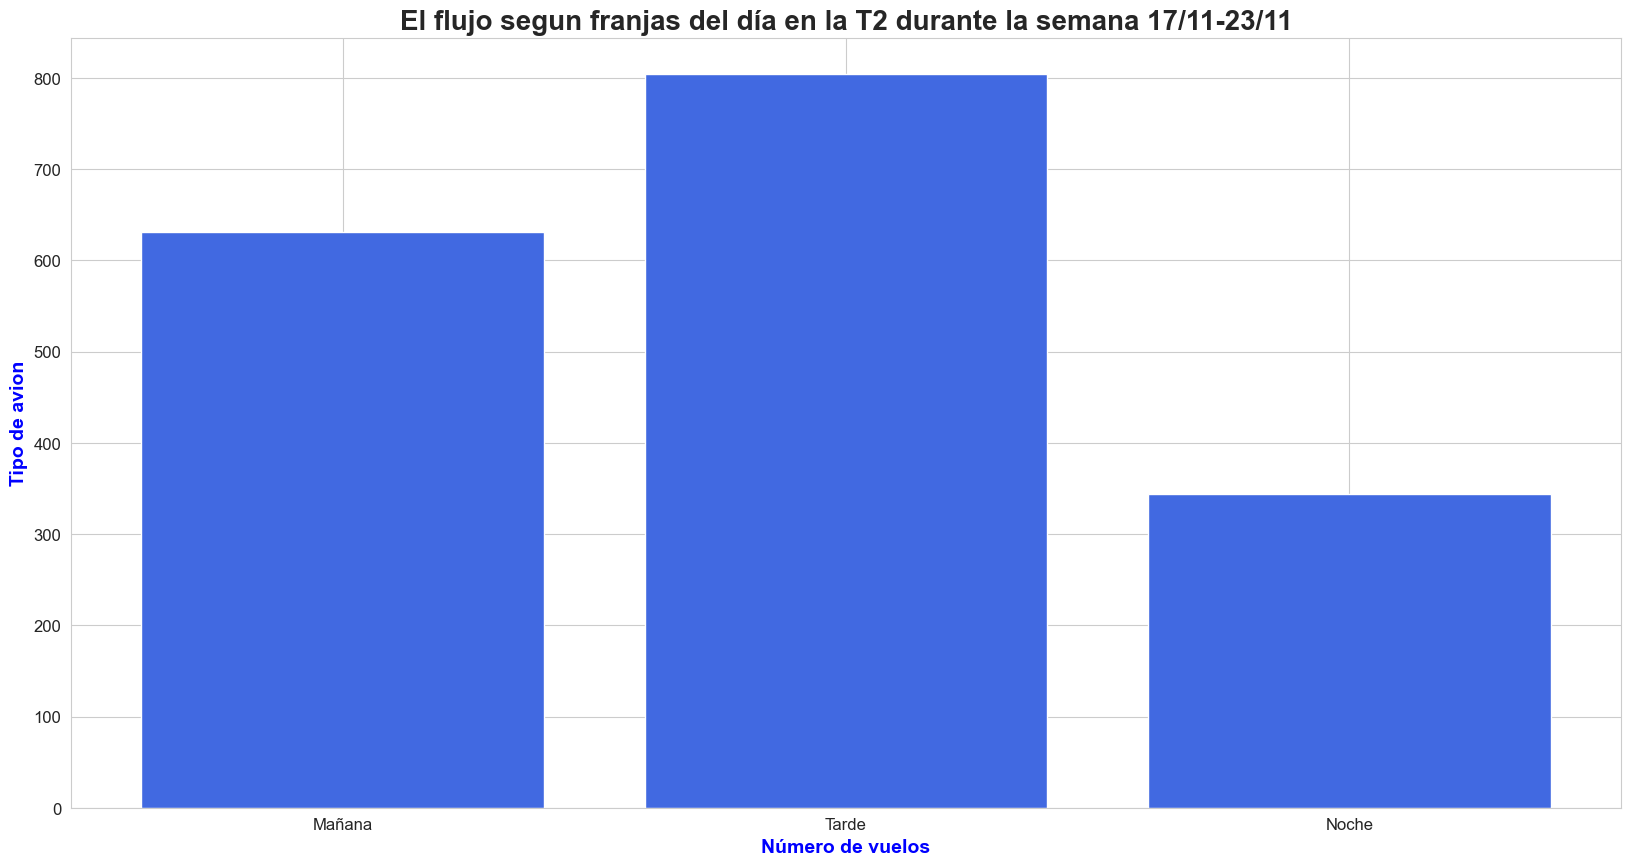

In [158]:
plt.figure(figsize=(20,10))
plt.bar(top5_sorted.index, top5_sorted.values, color="royalblue")

plt.title("El flujo segun franjas del día en la T2 durante la semana 17/11-23/11", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [159]:
#df.to_csv("vuelos_semanal_limpio1.csv") 

In [160]:
# Ver la capacidad

In [161]:
df_cn = (
    df_easy
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cn
# ARREGLAR A319 PARA QUE SU CAPACIDAD SEA 156

,Name_company,Aircraft,flight_capacity,count
0,Grupo easy,Airbus A319,156,151
1,Grupo easy,Airbus A320,180,70
2,Grupo easy,Airbus A320neo,186,22
3,Grupo easy,Airbus A321,230,9


In [162]:
df[(df['Aircraft'] == 'Airbus A320') & (df['Name_company'] == 'Grupo easy') &
(df['flight_capacity'] == 186)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [163]:
df_wizz = df[df['Name_company'] == 'Grupo wizz']

In [164]:
df_cw = (
    df_wizz
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

# Corregido
df_cw

,Name_company,Aircraft,flight_capacity,count
0,Grupo wizz,Airbus A320,180,32
1,Grupo wizz,Airbus A320neo,186,3
2,Grupo wizz,Airbus A321,230,54
3,Grupo wizz,Airbus A321neo,239,178


In [165]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Grupo wizz') &
(df['flight_capacity'] == 186)]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
444,2025-11-20,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,S,EU,Jueves,Noche
604,2025-11-21,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,186,Airbus A320neo,R,EU,Viernes,Noche
1048,2025-11-24,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,Retrasado,186,Airbus A320neo,S,EU,Lunes,Noche


In [166]:
df_ryr = df[df['Name_company'] == 'Grupo Ryanair']

In [167]:
df_cy = (
    df_ryr
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_cy
# CorregiFR3180do!

,Name_company,Aircraft,flight_capacity,count
0,Grupo Ryanair,Airbus A320,180,32
1,Grupo Ryanair,Boeing 737 MAX 8,197,204
2,Grupo Ryanair,Boeing 737-800,189,606


In [168]:
df[(df['Aircraft'] == 'Airbus A321neo') & (df['Name_company'] == 'Grupo Ryanair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [169]:
df_t = df[df['Name_company'] == 'Transavia']

In [170]:
df_tr = (
    df_t
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_tr

,Name_company,Aircraft,flight_capacity,count
0,Transavia,Airbus A320neo,186,21
1,Transavia,Airbus A321neo,232,14
2,Transavia,Boeing 737-800,189,34


In [171]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Transavia')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [172]:
df_v = df[df['Name_company'] == 'Volotea']

In [173]:
df_vl = (
    df_v
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_vl
# CORREGIdo !

,Name_company,Aircraft,flight_capacity,count
0,Volotea,Airbus A319,156,19
1,Volotea,Airbus A320,180,39


In [174]:
df[(df['Aircraft'] == 'Airbus A319') & (df['Name_company'] == 'Volotea')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
27,2025-11-17,Volotea,V73573,Asturias (OVD),09:30:00,Retrasado,156,Airbus A319,S,NAC,Lunes,Mañana
108,2025-11-17,Volotea,V73700,Vitoria (VIT),17:15:00,En hora,156,Airbus A319,S,NAC,Lunes,Tarde
150,2025-11-17,Volotea,V72165,Nantes/Atlantique (NTE),20:50:00,Retrasado,156,Airbus A319,R,EU,Lunes,Noche
395,2025-11-20,Volotea,V73573,Asturias (OVD),16:05:00,En hora,156,Airbus A319,S,NAC,Jueves,Tarde
538,2025-11-21,Volotea,V73735,Murcia (RMU),15:15:00,Retrasado,156,Airbus A319,S,NAC,Viernes,Tarde
554,2025-11-21,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,S,NAC,Viernes,Tarde
570,2025-11-21,Volotea,V72165,Nantes/Atlantique (NTE),19:30:00,En hora,156,Airbus A319,S,EU,Viernes,Tarde
830,2025-11-23,Volotea,V73573,Asturias (OVD),17:40:00,En hora,156,Airbus A319,S,NAC,Domingo,Tarde
850,2025-11-23,Volotea,V72165,Nantes/Atlantique (NTE),19:30:00,En hora,156,Airbus A319,S,EU,Domingo,Tarde
921,2025-11-24,Volotea,V73573,Asturias (OVD),09:30:00,En hora,156,Airbus A319,U,NAC,Lunes,Mañana


In [175]:
df_e = df[df['Name_company'] == 'Eurowings']

In [176]:
df_ew = (
    df_e
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ew


,Name_company,Aircraft,flight_capacity,count
0,Eurowings,Airbus A319,150,9
1,Eurowings,Airbus A320,180,18
2,Eurowings,Airbus A320neo,180,1
3,Eurowings,Airbus A321,226,3
4,Eurowings,Airbus A321neo,232,4


In [177]:
df[(df['Aircraft'] == 'Airbus A321') & (df['Name_company'] == 'Eurowings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
275,2025-11-19,Eurowings,EW521,Cologne-Bonn (CGN),13:25:00,Retrasado,226,Airbus A321,U,EU,Miércoles,Tarde
576,2025-11-21,Eurowings,EW2521,Stuttgart (STR),19:55:00,Retrasado,226,Airbus A321,U,EU,Viernes,Tarde
1017,2025-11-24,Eurowings,EW7521,Hamburg (HAM),19:40:00,En hora,226,Airbus A321,U,EU,Lunes,Tarde


In [178]:
df_p = df[df['Name_company'] == 'Pegasus Airlines']

In [179]:
df_pg = (
    df_p
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_pg


,Name_company,Aircraft,flight_capacity,count
0,Pegasus Airlines,Airbus A320,180,6
1,Pegasus Airlines,Airbus A321,220,10
2,Pegasus Airlines,Airbus A321neo,239,8


In [180]:
df[(df['Aircraft'] == 'Boeing 737-800') & (df['Name_company'] == 'Pegasus Airlines')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [181]:
df_m = df[df['Name_company'] == 'Air Arabia Maroc']

In [182]:
df_mm = (
    df_m
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_mm

,Name_company,Aircraft,flight_capacity,count
0,Air Arabia Maroc,Airbus A320,174,36


In [183]:
df_n = df[df['Name_company'] == 'Norwegian Air Sweden AOC']

In [184]:
df_nw = (
    df_n
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_nw

,Name_company,Aircraft,flight_capacity,count
0,Norwegian Air Sweden AOC,Boeing 737 MAX 8,189,8
1,Norwegian Air Sweden AOC,Boeing 737-800,189,25


In [185]:
df_l = df[df['Name_company'] == 'Aer Lingus']

In [186]:
df_ln = (
    df_l
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ln

,Name_company,Aircraft,flight_capacity,count
0,Aer Lingus,Airbus A320,174,20
1,Aer Lingus,Airbus A320neo,186,2


In [187]:
df[(df['Aircraft'] == 'Airbus A320neo') & (df['Name_company'] == 'Aer Lingus')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
780,2025-11-23,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,W,INT,Domingo,Mañana
1665,2025-11-30,Aer Lingus,EI563,Dublin (DUB),11:30:00,En hora,186,Airbus A320neo,W,INT,Domingo,Mañana


In [188]:
df_s = df[df['Name_company'] == 'Air Serbia']

In [189]:
df_sb = (
    df_s
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sb

,Name_company,Aircraft,flight_capacity,count
0,Air Serbia,Airbus A319,144,17


In [190]:
df_j = df[df['Name_company'] == 'Jet2']

In [191]:
df_jt = (
    df_j
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_jt

,Name_company,Aircraft,flight_capacity,count
0,Jet2,Airbus A321neo,232,1
1,Jet2,Boeing 737 MAX 8,189,1
2,Jet2,Boeing 737-800,189,11


In [192]:
df[(df['Aircraft'] == 'Airbus A321neo') & (df['Name_company'] == 'Jet2')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
858,2025-11-23,Jet2,LS1338,Birmingham (BHX),19:55:00,Retrasado,232,Airbus A321neo,W,INT,Domingo,Tarde


In [193]:
df_b = df[df['Name_company'] == 'Air Baltic']

In [194]:
df_bl = (
    df_b
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bl

,Name_company,Aircraft,flight_capacity,count
0,Air Baltic,Airbus A220-300,148,14


In [195]:
df[(df['flight_capacity'] == 145) & (df['Name_company'] == 'Air Baltic')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [196]:
df_lx = df[df['Name_company'] == 'Luxair']

In [197]:
df_xlx = (
    df_lx
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_xlx

,Name_company,Aircraft,flight_capacity,count
0,Luxair,Boeing 737-700,141,2
1,Luxair,Boeing 737-800,186,3
2,Luxair,de Havilland Dash 8-400,76,6


In [198]:
df[(df['flight_capacity'] == 142) & (df['Name_company'] == 'Luxair')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [199]:
df_ba = df[df['Name_company'] == 'Bluebird Airways']

In [200]:
df_bla = (
    df_ba
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_bla

,Name_company,Aircraft,flight_capacity,count
0,Bluebird Airways,Airbus A320,180,4
1,Bluebird Airways,Boeing 737-800,189,7


In [201]:
df_sw = df[df['Name_company'] == 'SmartWings']

In [202]:
df_swg = (
    df_sw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_swg

,Name_company,Aircraft,flight_capacity,count
0,SmartWings,Airbus A220-300,149,2
1,SmartWings,Boeing 737-800,189,6


In [203]:
df[(df['flight_capacity'] == 149) & (df['Name_company'] == 'SmartWings')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
1276,2025-11-27,SmartWings,QS1059,Prague (PRG),14:55:00,En hora,149,Airbus A220-300,U,EU,Jueves,Tarde
1417,2025-11-28,SmartWings,QS1059,Prague (PRG),14:55:00,En hora,149,Airbus A220-300,U,EU,Viernes,Tarde


In [204]:
df_tw = df[df['Name_company'] == "T'Way Air"]

In [205]:
df_twa = (
    df_tw
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_twa

,Name_company,Aircraft,flight_capacity,count
0,T'Way Air,Airbus A330-200,246,4
1,T'Way Air,BOEING 777-300ER,294,4


In [206]:
df[(df['flight_capacity'] == 275) & (df['Name_company'] == "T'Way Air")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time


In [207]:
df_az = df[df['Name_company'] == "Azerbaijan Airlines"]

In [208]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza  # correcto a320

,Name_company,Aircraft,flight_capacity,count
0,Azerbaijan Airlines,Airbus A319,122,2
1,Azerbaijan Airlines,Airbus A320,174,1
2,Azerbaijan Airlines,Airbus A320neo,186,5


In [239]:
df[(df['flight_capacity'] == 174) & (df['Name_company'] == "Azerbaijan Airlines")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
1662,2025-11-30,Azerbaijan Airlines,J246,Baku (GYD),10:45:00,Retrasado,174,Airbus A320,Y,INT,Domingo,Mañana


In [209]:
df_k = df[df['Name_company'] == "Kuwait Airways"]

In [210]:
df_kw = (
    df_k
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_kw

,Name_company,Aircraft,flight_capacity,count
0,Kuwait Airways,Airbus A330-800,235,2
1,Kuwait Airways,Airbus A330-900,278,4


In [211]:
df_tk = df[df['Name_company'] == "Turkish Airlines"]

In [212]:
df_trk = (
    df_tk
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_trk

,Name_company,Aircraft,flight_capacity,count
0,Turkish Airlines,Boeing 737-800,165,6


In [213]:
df_ic = df[df['Name_company'] == "Icelandair"]

In [214]:
df_ice = (
    df_ic
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_ice

,Name_company,Aircraft,flight_capacity,count
0,Icelandair,Boeing 737 MAX 8,160,5
1,Icelandair,Boeing 757-200,184,1


In [215]:
df_se = df[df['Name_company'] == "SunExpress"]

In [216]:
df_sun = (
    df_se
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_sun

,Name_company,Aircraft,flight_capacity,count
0,SunExpress,Boeing 737-800,189,4


In [217]:
df_sky = df[df['Name_company'] == "SkyUp MT"]

In [218]:
df_smt = (
    df_sky
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_smt

,Name_company,Aircraft,flight_capacity,count
0,SkyUp MT,Boeing 737-700,149,4


In [219]:
df_hi = df[df['Name_company'] == "HiSky"]

In [220]:
df_hik = (
    df_hi
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_hik

,Name_company,Aircraft,flight_capacity,count
0,HiSky,Airbus A320,186,4


In [221]:
df_fl = df[df['Name_company'] == "FlyOne"]

In [222]:
df_flo = (
    df_fl
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_flo

,Name_company,Aircraft,flight_capacity,count
0,FlyOne,Airbus A320,180,3
1,FlyOne,Airbus A321,194,1


In [240]:
df[(df['flight_capacity'] == 194) & (df['Name_company'] == "FlyOne")]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
206,2025-11-18,FlyOne,5F5512,Chisinau (KIV),13:30:00,En hora,194,Airbus A321,W,INT,Martes,Tarde


In [223]:
df_ar = df[df['Name_company'] == "FLYONE Armenia"]

In [224]:
df_arm = (
    df_ar
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_arm

,Name_company,Aircraft,flight_capacity,count
0,FLYONE Armenia,Airbus A320,180,3


In [225]:
df_az = df[df['Name_company'] == "Azores Airlines"]

In [226]:
df_aza = (
    df_az
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_aza

,Name_company,Aircraft,flight_capacity,count
0,Azores Airlines,Airbus A320neo,186,1


In [227]:
df_ib = df[df['Name_company'] == "Iberojet"]

In [228]:
df_iber = (
    df_ib
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_iber

,Name_company,Aircraft,flight_capacity,count
0,Iberojet,Airbus A350-900,432,2


In [229]:
df_bol = df[df['Name_company'] == "Boliviana de Aviacion"]

In [230]:
df_avi = (
    df_bol
    .groupby(['Name_company', 'Aircraft', 'flight_capacity'])
    .size()
    .reset_index(name='count')
)

df_avi

,Name_company,Aircraft,flight_capacity,count
0,Boliviana de Aviacion,Airbus A330-200,246,2


In [231]:
df[(df['flight_capacity'] == 246) & (df['Name_company'] == 'Boliviana de Aviacion')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
668,2025-11-22,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde
1550,2025-11-29,Boliviana de Aviacion,OB775,Santa Cruz (VVI),13:10:00,Retrasado,246,Airbus A330-200,Y,INT,Sábado,Tarde


In [232]:
"""
df['Gate'] = df.groupby(
    ['International_flag', 'Name_company', 'Name_Destiny']
)['Gate'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

"""

"\ndf['Gate'] = df.groupby(\n    ['International_flag', 'Name_company', 'Name_Destiny']\n)['Gate'].transform(\n    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)\n)\n\n"

In [233]:
df.reset_index(drop=True, inplace=True)

In [234]:
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,NaN,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
1774,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
1775,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo,Noche
1776,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo,Noche
1777,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo,Noche


In [243]:
df_moda = df.groupby(['Name_company', 'Type_f', 'Gate']).size().reset_index(name='count')
df_moda.sort_values(['Name_company'])

,Name_company,Type_f,Gate,count
0,AJet 608,INT,W,1
1,Aer Lingus,INT,W,9
2,Aer Lingus,INT,Y,13
3,Air Arabia Maroc,INT,W,13
4,Air Arabia Maroc,INT,Y,20
...,...,...,...,...
73,Volotea,EU,U,10
75,Volotea,NAC,S,15
71,Volotea,EU,R,4
72,Volotea,EU,S,23


## **16 NANS EN GATE/ 6 INT 10 EU /** 
#### 6 INT: (A TRAVES DE LA OBSERVACIÓN)
- 3 GATES FALTANTE, AIR ARABIA -> Y (+ FRECUENTE)
- 2 GATES, RYR -> W
- 1 GATE, WIZZ -> W
#### 10 EU:
- 3 GATES, TRANSAVIA -> U
- 5 GATES, WIZZ -> S
- 2 GATES, RYR -> U

PARA IMPUTAR GATES -> MODA(+ FRECUENCIA)pero CONDICIONAL BASADA EN EL TIPO Y LA COMPAÑIA

In [245]:
import pandas as pd

# Definir la función para obtener la moda (el primer valor si hay empate)
def get_mode(series):
    return series.mode().iloc[0]

# 2. Agrupar por las variables condicionales y usar transform 
#para obtener la moda de cada grupo
# Las columnas condicionales son 'Name_company' y 'Type_f'
moda_condicional = df.groupby(['Name_company', 'Type_f'])['Gate'].transform(get_mode)

# 3. Rellenar los valores NaN de la columna 'Gate' en el DataFrame original 'df'
df['Gate'] = df['Gate'].fillna(moda_condicional)

# Ahora el DataFrame 'df' tiene las Gates imputadas condicionalmente.
df

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
0,2025-11-17,Grupo Ryanair,FR3180,Rome (FCO),06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana
1,2025-11-17,Grupo Ryanair,FR846,Milan (BGY),06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana
2,2025-11-17,Grupo easy,EC7105,Geneva (GVA),06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana
3,2025-11-17,Grupo Ryanair,FR2233,Al Aaroui (NDR),06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana
4,2025-11-17,Grupo Ryanair,FR8384,Budapest (BUD),06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana
...,...,...,...,...,...,...,...,...,...,...,...,...
1774,2025-11-30,Grupo wizz,W64116,Belgrade (BEG),21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche
1775,2025-11-30,Grupo wizz,W45154,Tirana (TIA),22:45:00,Retrasado,230,Airbus A321,W,INT,Domingo,Noche
1776,2025-11-30,Grupo Ryanair,FR5220,Bologna (BLQ),22:50:00,En hora,197,Boeing 737 MAX 8,S,EU,Domingo,Noche
1777,2025-11-30,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,230,Airbus A321,U,EU,Domingo,Noche


In [246]:
df.isna().sum()

fecha_scrapeo      0
Name_company       0
Num_flight         0
Name_Destiny       0
Time_flight        0
flight_state       0
flight_capacity    0
Aircraft           0
Gate               0
Type_f             0
week_day           0
day_time           0
dtype: int64

In [250]:
df[(df['Type_f'] == 'EU') & (df['Name_company'] == 'Grupo wizz')][100:110]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time
845,2025-11-23,Grupo wizz,W61478,Warsaw (WAW),19:00:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
847,2025-11-23,Grupo wizz,W43180,Bucharest (OTP),19:05:00,En hora,230,Airbus A321,U,EU,Domingo,Tarde
852,2025-11-23,Grupo wizz,W64406,Sofia (SOF),19:35:00,En hora,239,Airbus A321neo,U,EU,Domingo,Tarde
861,2025-11-23,Grupo wizz,W62096,Krakow (KRK),20:10:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
864,2025-11-23,Grupo wizz,W67022,Bratislava (BTS),20:20:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche
872,2025-11-23,Grupo wizz,W62378,Budapest (BUD),20:45:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
882,2025-11-23,Grupo wizz,W43178,Bucharest (BBU),21:20:00,En hora,230,Airbus A321,U,EU,Domingo,Noche
883,2025-11-23,Grupo wizz,W43406,Cluj-Napoca (CLJ),21:25:00,En hora,180,Airbus A320,S,EU,Domingo,Noche
885,2025-11-23,Grupo wizz,W46020,Rome (FCO),21:35:00,Retrasado,239,Airbus A321neo,S,EU,Domingo,Noche
892,2025-11-23,Grupo wizz,W61706,Gdansk (GDN),22:50:00,En hora,239,Airbus A321neo,U,EU,Domingo,Noche


In [253]:
#df.to_csv("vuelos_TODO_LIMPIO.csv") 

In [236]:
#unir ha salido con programado y en hora 

In [237]:
# if df['Type_f'] =  df(df['Name_Destiny'] == vuelos_INT) = 'INT'
# if df['Gate'] == 'W' or 'y' -> 'internacional' 
# if df['Name_Destiny'] == vuelos nacionales == 'NATION' else == 'EU'

In [238]:
# CRAR VARIABLE DIA DE LA SEMANA(LU,MA, MIE,JUE, VIE, SA, DOM) ESTANDARIZAR FECHA, 